# (A-1b) Analýza štruktúr dát ako súbory (štruktúry a vzťahy, počet, typy, …), záznamy (štruktúry, počet záznamov, počet atribútov, typy, …)

## Imports

In [1]:
# noinspection PyPackageRequirements
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import normaltest, anderson
from scipy.stats import shapiro
from scipy.stats import spearmanr
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 

### Load datasets and make copies

In [2]:
# Load original datasets
df1_original = pd.read_csv("001/observation.csv", sep='\t')
df2_original = pd.read_csv("001/patient.csv", sep='\t')
df3_original = pd.read_csv("001/station.csv", sep='\t')
info_data = pd.read_csv("001/additional_info/sensor_variable_range.csv", sep='\t')

# Define copy folder and copy filenames
copy_folder = "001/copy"
copy1_file = os.path.join(copy_folder, "observation_copy.csv")
copy2_file = os.path.join(copy_folder, "patient_copy.csv")
copy3_file = os.path.join(copy_folder, "station_copy.csv")

# Delete old copies if folder exists
if os.path.exists(copy_folder):
    shutil.rmtree(copy_folder)

# Create new folder
os.makedirs(copy_folder)

# Make copies in memory and save to folder
df1_copy = df1_original.copy()
df1_copy.to_csv(copy1_file, index=False, sep='\t')

df2_copy = df2_original.copy()
df2_copy.to_csv(copy2_file, index=False, sep='\t')

df3_copy = df3_original.copy()
df3_copy.to_csv(copy3_file, index=False, sep='\t')

# Load copies to work with them
df1 = pd.read_csv(copy1_file, sep='\t')
df2 = pd.read_csv(copy2_file, sep='\t')
df3 = pd.read_csv(copy3_file, sep='\t')

In [3]:
df1.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.287434,72.727986,13.660737,15.755854,39.737731,49.035774,87.868263,99.655904,35.376585,7.955277,...,4.033183,42.295962,65.648070,51.192423,38.744548,0.229549,25.836222,1.0,35.06544,1.04945
1,98.537124,73.435702,4.453073,15.925616,40.015592,76.884562,76.449362,99.778323,36.578250,10.290540,...,4.033908,50.848705,70.175689,54.580531,44.654611,0.229253,22.657638,1.0,23.56540,119.58627
2,99.126826,74.484895,14.230313,16.793470,38.773612,65.426955,76.714834,111.320081,34.413950,7.645887,...,4.043543,65.903650,41.081781,50.899240,36.904112,0.221017,30.960610,1.0,48.79325,2.29275
3,98.699062,72.789517,3.295218,16.537063,40.458715,54.228426,84.446027,100.136492,36.216960,12.364709,...,4.033551,62.965616,70.826093,37.521845,65.873715,0.263626,34.126183,1.0,60.02427,30.28491
4,96.775490,81.687039,4.805640,15.542213,38.756204,67.977808,127.867499,104.221144,35.304788,13.230194,...,4.137927,57.341283,25.620538,64.705098,52.729143,0.219447,21.006023,0.0,-5.85746,144.23058


In [4]:
df2.head()

,username,user_id,address,residence,name,job,company,blood_group,mail,ssn,current_location,registration,station_ID
0,bsaito,167,福井県横浜市磯子区丸の内ＪＰタワー7丁目17番15号 大京町パレス520,NaN,坂本 晃,検察官,有限会社加藤ガス,AB-,yyamada@gmail.com,729-73-2197,"(Decimal('-4.6558885'), Decimal('-142.004537'))",2024-09-18,167
1,lesterangela,373,"4225 Kevin Knoll Suite 019\nRobertstad, IA 47461",NaN,Tommy Perry,Animal technologist,"Jones, Hall and Skinner",B+,charlesbrown@yahoo.com,541-38-7923,"(Decimal('88.6577465'), Decimal('-153.040860'))","04/26/2023, 00:00:00",619
2,ikedashota,551,奈良県小笠原村睦1丁目2番4号 コーポ卯の里127,NaN,佐藤 智也,NaN,吉田建設株式会社,A-,tanakamiki@hotmail.com,895-36-0135,"(Decimal('-39.406022'), Decimal('-23.863964'))",05 Mar 2023,339
3,satomiki,575,沖縄県富里市京橋16丁目24番5号 木立シティ589,NaN,高橋 明美,NaN,有限会社山下鉱業,O-,yui92@yahoo.com,144-28-2820,"(Decimal('-81.2785545'), Decimal('-102.751595'))",12 Apr 2023,739
4,abetaichi,439,NaN,NaN,加藤 舞,イラストレーター,石井ガス合同会社,O-,takumakimura@yahoo.com,451-43-0174,"(Decimal('44.751933'), Decimal('117.007218'))",08 Feb 2022,166


In [5]:
df3.head()

,longitude,latitude,code,revision,station,location
0,126.83500,37.65639,KR,"11/24/2021, 00:00:00",Goyang-si,Asia/Seoul
1,71.67164,30.29184,PK,27 Sep 2017,Qadirpur Ran,Asia/Karachi
2,3.87723,43.61092,FR,2021/09/21,Montpellier,Europe/Paris
3,-58.70072,-34.74785,AR,2019/11/16,Pontevedra,America/Argentina/Buenos_Aires
4,139.68530,35.81500,JP,2024-04-21,Shimotoda,Asia/Tokyo


In [6]:
info_data

,Variable,Unit,Description,Value Range
0,SpO₂,%,Peripheral oxygen saturation,95–100%
1,HR,bpm,Heart rate from pulse oximeter,60–100 bpm
2,PI,%,Perfusion index,0.2–20%
3,RR,breaths/min,Respiratory rate,12–20 breaths/min
4,EtCO₂,mmHg,End-tidal carbon dioxide,35–45 mmHg
5,FiO₂,%,Fraction of inspired oxygen,21–100%
6,PRV,ms,Pulse rate variability,20–200 ms
7,BP,mmHg,Blood pressure (systolic diastolic mean),90/60–120/80 mmHg
8,Skin Temperature,°C,Peripheral temperature,33–38 °C
9,Motion/Activity index,-,Sensor artifact correction,NaN


We have three datasets

1. DF1 – physiological / sensor data (SpO₂, HR, etc.)

2. DF2 – user / patient metadata (username, job, blood group, etc.)

3. DF3 – location / station / administrative data

# 1.1 A - observation

In [7]:
df1.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.287434,72.727986,13.660737,15.755854,39.737731,49.035774,87.868263,99.655904,35.376585,7.955277,...,4.033183,42.295962,65.648070,51.192423,38.744548,0.229549,25.836222,1.0,35.06544,1.04945
1,98.537124,73.435702,4.453073,15.925616,40.015592,76.884562,76.449362,99.778323,36.578250,10.290540,...,4.033908,50.848705,70.175689,54.580531,44.654611,0.229253,22.657638,1.0,23.56540,119.58627
2,99.126826,74.484895,14.230313,16.793470,38.773612,65.426955,76.714834,111.320081,34.413950,7.645887,...,4.043543,65.903650,41.081781,50.899240,36.904112,0.221017,30.960610,1.0,48.79325,2.29275
3,98.699062,72.789517,3.295218,16.537063,40.458715,54.228426,84.446027,100.136492,36.216960,12.364709,...,4.033551,62.965616,70.826093,37.521845,65.873715,0.263626,34.126183,1.0,60.02427,30.28491
4,96.775490,81.687039,4.805640,15.542213,38.756204,67.977808,127.867499,104.221144,35.304788,13.230194,...,4.137927,57.341283,25.620538,64.705098,52.729143,0.219447,21.006023,0.0,-5.85746,144.23058


In [8]:
# Shape Observation
df1.shape

(12072, 23)

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12072 entries, 0 to 12071
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12072 non-null  float64
 1   HR                     12072 non-null  float64
 2   PI                     12072 non-null  float64
 3   RR                     12072 non-null  float64
 4   EtCO₂                  12072 non-null  float64
 5   FiO₂                   12072 non-null  float64
 6   PRV                    12072 non-null  float64
 7   BP                     12072 non-null  float64
 8   Skin Temperature       12072 non-null  float64
 9   Motion/Activity index  12072 non-null  float64
 10  PVI                    12072 non-null  float64
 11  Hb level               12072 non-null  float64
 12  SV                     12072 non-null  float64
 13  CO                     12072 non-null  float64
 14  Blood Flow Index       12072 non-null  float64
 15  PP

As we can see the dataset does not have any missing values, which is great. Lets check it again.

In [10]:
df1.isna().sum()
df1.isna().sum().sum() 

np.int64(0)

The info() was correct

In [11]:
df1.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,...,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000
mean,97.730285,79.254201,10.016369,15.626983,40.040860,59.329962,107.604654,103.727082,35.397460,9.830430,...,4.149888,51.762373,51.548528,47.794603,49.804995,0.249555,29.987667,0.593439,28.832118,13.196526
std,0.849037,5.438131,3.437076,0.956935,1.196779,9.797490,24.535197,3.711239,0.711471,3.075349,...,0.183781,12.830055,13.527842,12.725520,11.508852,0.028922,5.761799,0.491212,22.474840,72.476192
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,0.729104,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-37.900000,-156.474320
25%,97.107194,75.594604,7.223626,14.987305,39.293217,52.717795,91.139805,101.171379,34.876218,7.410571,...,4.050131,43.176123,42.364549,39.120478,42.091744,0.224552,24.977781,0.000000,13.445810,-53.137220
50%,97.735028,79.184384,10.653755,15.622879,40.078524,59.328839,107.694499,103.768896,35.390370,9.358351,...,4.091939,51.811911,51.376980,47.627465,49.855143,0.249152,30.067626,1.000000,35.800000,12.194580
75%,98.414264,82.949844,12.634827,16.269205,40.799402,65.967587,124.029275,106.271298,35.918449,12.479597,...,4.179315,60.288289,60.683865,56.484589,57.459824,0.274704,34.957534,1.000000,45.503690,72.545660
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,18.997281,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,152.704930


In [12]:
print("Unique SPO2: {}".format(df1['SpO₂'].nunique()))
print("Unique HR: {}".format(df1['HR'].nunique()))
print("Unique PI: {}".format(df1['PI'].nunique()))
print("Unique RR: {}".format(df1['RR'].nunique()))
print("Unique ETCO2: {}".format(df1['EtCO₂'].nunique()))
print("Unique FIO2: {}".format(df1['FiO₂'].nunique()))
print("Unique oximetry: {}".format(df1['oximetry'].nunique()))

Unique SPO2: 11894
Unique HR: 11894
Unique PI: 11894
Unique RR: 11894
Unique ETCO2: 11894
Unique FIO2: 11894
Unique oximetry: 2


We know that the dataset has 12000+ rows. Thus we can say this looks suspisious that each culumn results in the same number of unique values. Maybe there are duplicates.. I am not yet sure if the representation of these data is correct if we need floating points. Maybe we need to know heart rate in N number rather than float number

In [13]:
df1.isnull().sum()

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64

In the df1 there are no nan values

In [14]:
print("Total rows:", len(df1))
print("Unique rows:", len(df1.drop_duplicates()))

Total rows: 12072
Unique rows: 12072


Check if the data is in specific range

In [15]:
# Define the expected ranges for each variable
value_ranges = {
    'SpO₂': (95, 100),
    'HR': (60, 100),
    'PI': (0.2, 20),
    'RR': (12, 20),
    'EtCO₂': (35, 45),
    'FiO₂': (21, 100),
    'PRV': (20, 200),
    'BP': (90, 120),  # Assuming systolic mean for simplicity
    'Skin Temperature': (33, 38),
    'PVI': (10, 20),
    'Hb level': (12, 18),
    'SV': (60, 100),
    'CO': (4, 8),
    'Signal Quality Index': (0, 100),
    'O₂ extraction ratio': (0.2, 0.3),
    'SNR': (20, 40)
}

# Loop through the variables and check for values outside the expected range
for col, (low, high) in value_ranges.items():
    if col in df1.columns:
        out_of_range = df1[(df1[col] < low) | (df1[col] > high)]
        print(f"{col}: {len(out_of_range)} values outside the range ({low}-{high})")

SpO₂: 0 values outside the range (95-100)
HR: 0 values outside the range (60-100)
PI: 0 values outside the range (0.2-20)
RR: 0 values outside the range (12-20)
EtCO₂: 0 values outside the range (35-45)
FiO₂: 0 values outside the range (21-100)
PRV: 0 values outside the range (20-200)
BP: 0 values outside the range (90-120)
Skin Temperature: 0 values outside the range (33-38)
PVI: 0 values outside the range (10-20)
Hb level: 0 values outside the range (12-18)
SV: 0 values outside the range (60-100)
CO: 0 values outside the range (4-8)
Signal Quality Index: 0 values outside the range (0-100)
O₂ extraction ratio: 0 values outside the range (0.2-0.3)
SNR: 0 values outside the range (20-40)


# We need to check if each sensor data is from any specific station, if not probably we dont want it since it can be missleading
- will be done in A2 after transforming the data

No duplicate records.

## **DF1**
- has 12 072 unique rows with 23 attributes
- each record represents one timestamped observation of physiological measurements
- every attribute is float64 without missing values
- The attributes are physiologically dependent
- Values are in desired range

# 1.1 A - patient

In [16]:
df2.head()

,username,user_id,address,residence,name,job,company,blood_group,mail,ssn,current_location,registration,station_ID
0,bsaito,167,福井県横浜市磯子区丸の内ＪＰタワー7丁目17番15号 大京町パレス520,NaN,坂本 晃,検察官,有限会社加藤ガス,AB-,yyamada@gmail.com,729-73-2197,"(Decimal('-4.6558885'), Decimal('-142.004537'))",2024-09-18,167
1,lesterangela,373,"4225 Kevin Knoll Suite 019\nRobertstad, IA 47461",NaN,Tommy Perry,Animal technologist,"Jones, Hall and Skinner",B+,charlesbrown@yahoo.com,541-38-7923,"(Decimal('88.6577465'), Decimal('-153.040860'))","04/26/2023, 00:00:00",619
2,ikedashota,551,奈良県小笠原村睦1丁目2番4号 コーポ卯の里127,NaN,佐藤 智也,NaN,吉田建設株式会社,A-,tanakamiki@hotmail.com,895-36-0135,"(Decimal('-39.406022'), Decimal('-23.863964'))",05 Mar 2023,339
3,satomiki,575,沖縄県富里市京橋16丁目24番5号 木立シティ589,NaN,高橋 明美,NaN,有限会社山下鉱業,O-,yui92@yahoo.com,144-28-2820,"(Decimal('-81.2785545'), Decimal('-102.751595'))",12 Apr 2023,739
4,abetaichi,439,NaN,NaN,加藤 舞,イラストレーター,石井ガス合同会社,O-,takumakimura@yahoo.com,451-43-0174,"(Decimal('44.751933'), Decimal('117.007218'))",08 Feb 2022,166


In [17]:
df2.shape

(2094, 13)

In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2094 entries, 0 to 2093
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   username          2094 non-null   object 
 1   user_id           2094 non-null   int64  
 2   address           1780 non-null   object 
 3   residence         0 non-null      float64
 4   name              2094 non-null   object 
 5   job               628 non-null    object 
 6   company           2094 non-null   object 
 7   blood_group       2094 non-null   object 
 8   mail              2094 non-null   object 
 9   ssn               2094 non-null   object 
 10  current_location  1989 non-null   object 
 11  registration      2094 non-null   object 
 12  station_ID        2094 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 212.8+ KB


Residence seems off. Also it has 2094 missing values. We can remove this column since it has no value for us.
Otherwise good data types. Some nan values for few attributes.

In [19]:
df2.isna().sum()

username               0
user_id                0
address              314
residence           2094
name                   0
job                 1466
company                0
blood_group            0
mail                   0
ssn                    0
current_location     105
registration           0
station_ID             0
dtype: int64

In [20]:
df2.isna().sum().sum() 

np.int64(3979)

In [21]:
df2.duplicated().sum()

np.int64(0)

In [22]:
# Check overall duplicates (any row identical)
print("Overall duplicate rows:", df2.duplicated().sum())

# Check duplicates by user_id
print("Duplicate user_id values:", df2['user_id'].duplicated().sum())

# Check duplicates by ssn
print("Duplicate SSN values:", df2['ssn'].duplicated().sum())



Overall duplicate rows: 0
Duplicate user_id values: 767
Duplicate SSN values: 0


In [23]:
df2[df2['user_id'].duplicated(keep=False)].sort_values('user_id')


,username,user_id,address,residence,name,job,company,blood_group,mail,ssn,current_location,registration,station_ID
2054,weihmannmartin,4,Henkweg 91-38\n91757 Warendorf,NaN,Janine Holt-Naser,NaN,Steckel GmbH & Co. KGaA,A+,adolfbaerer@gmail.com,291-49-2286,"(Decimal('25.2065795'), Decimal('-11.979903'))",2019/08/15,246
574,fiorenzobianchini,4,"Borgo Girolamo, 81\n12063, Dogliani (CN)",NaN,Michele Barcaccia,NaN,"Gasperi, Palombi e Cuomo s.r.l.",O+,solaricesare@tim.it,MRTRMN28H19B726C,"(Decimal('-49.4508205'), Decimal('-66.957969'))",19 May 2022,754
543,hans-friedrichkoch-ii,6,Heino-Gorlitz-Weg 23/39\n02973 Stade,NaN,Dipl.-Ing. Hertha Pieper B.Sc.,NaN,Klemm Röhricht KG,A+,mariansiering@gmail.com,350-74-0392,"(Decimal('36.404929'), Decimal('151.365799'))",29 May 2025,753
1131,ryohei69,6,山形県羽村市鍛冶ケ沢38丁目20番13号 アーバン平河町110,NaN,山下 修平,NaN,株式会社小林保険,O-,yamamotorei@gmail.com,485-26-4121,"(Decimal('-80.3508175'), Decimal('140.898954'))","11/01/2024, 00:00:00",394
128,beatrice17,14,"Borgo Orlando, 0\n34128, Trieste (TS)",NaN,Dott. Fabrizia Ziani,NaN,"Mercati, Guarneri e Borromeo Group",O-,pisacanerenata@tele2.it,BZZNTT87P22C128X,"(Decimal('8.6570905'), Decimal('-168.634523'))","12/29/2020, 00:00:00",327
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,satotaichi,2089,山梨県練馬区箪笥町11丁目27番9号 京橋シティ588,NaN,渡辺 知実,NaN,田中運輸有限会社,O+,wkondo@hotmail.com,154-37-5817,"(Decimal('15.3416035'), Decimal('54.245550'))","11/18/2021, 00:00:00",509
1564,zadler,2091,Dorothee-Köhler-Platz 16-34\n00679 Hildesheim,NaN,Ing. Sarina Zahn,Winzer,Putz Butte AG & Co. KG,O+,franz-josef09@googlemail.com,302-11-5730,"(Decimal('4.761709'), Decimal('94.732987'))",2022-03-07,204
1840,fernandesenzo-gabriel,2091,NaN,NaN,Levi Sampaio,NaN,Vieira Almeida S/A,B-,asafecasa-grande@hotmail.com,72639418564,"(Decimal('-47.3017775'), Decimal('167.840323'))",2018-11-07,752
367,asukawatanabe,2092,大阪府中野区東和町19丁目16番2号 パレス浅草980,NaN,木村 直子,医師,株式会社三浦水産,AB+,atsushi24@gmail.com,089-73-4915,"(Decimal('65.279710'), Decimal('-158.649030'))","08/24/2019, 00:00:00",758


In [24]:
# Define valid blood groups
valid_blood_groups = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']

# Find rows where blood_group is NOT valid
wrong_val = df2[~df2['blood_group'].isin(valid_blood_groups)]

print(f"Number of wrong/invalid blood group values: {len(wrong_val)}")
display(wrong_val[['blood_group']])


Number of wrong/invalid blood group values: 0


,blood_group


# **DF2**
- It has 2094 number of records with 13 attributes
- Residence attribute has no entry, all is nan
- No duplicates
- Some missing values
- We will need to remove one column and fill others with unknown for example
- Current location doesnt follow the same format
- We need to adjust so that each attribute has one format
- Registration has time and data we will stick to date since others does not have date
- Current location is needed to be changed to other format
- Somehow there is duplicates of userid
- Since userid does not meat criteria we will use ssn as identifier because it has no duplicates
- The blood types are correct

# 1.1 A - station

In [25]:
df3.shape

(806, 6)

In [26]:
df3.head()

,longitude,latitude,code,revision,station,location
0,126.83500,37.65639,KR,"11/24/2021, 00:00:00",Goyang-si,Asia/Seoul
1,71.67164,30.29184,PK,27 Sep 2017,Qadirpur Ran,Asia/Karachi
2,3.87723,43.61092,FR,2021/09/21,Montpellier,Europe/Paris
3,-58.70072,-34.74785,AR,2019/11/16,Pontevedra,America/Argentina/Buenos_Aires
4,139.68530,35.81500,JP,2024-04-21,Shimotoda,Asia/Tokyo


In [27]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   longitude  806 non-null    float64
 1   latitude   806 non-null    float64
 2   code       805 non-null    object 
 3   revision   806 non-null    object 
 4   station    806 non-null    object 
 5   location   806 non-null    object 
dtypes: float64(2), object(4)
memory usage: 37.9+ KB


In [28]:
df3.isna().sum()

longitude    0
latitude     0
code         1
revision     0
station      0
location     0
dtype: int64

In [29]:
df3.duplicated().sum()

np.int64(0)

In [30]:
# Check overall duplicates (any row identical)
print("Overall duplicate rows:", df3.duplicated().sum())

# Check duplicated stations
duplicates_station_coords = df3[df3.duplicated(subset=['station', 'longitude', 'latitude', 'location'], keep=False)]
print(f"Number of true duplicate station records: {duplicates_station_coords.shape[0]}")
display(duplicates_station_coords.head())

duplicates_coords = df3[df3.duplicated(subset=['longitude', 'latitude'], keep=False)]
print(f"Number of repeated coordinates: {duplicates_coords.shape[0]}")
display(duplicates_coords.head())


Overall duplicate rows: 0
Number of true duplicate station records: 454


,longitude,latitude,code,revision,station,location
0,126.83500,37.65639,KR,"11/24/2021, 00:00:00",Goyang-si,Asia/Seoul
1,71.67164,30.29184,PK,27 Sep 2017,Qadirpur Ran,Asia/Karachi
3,-58.70072,-34.74785,AR,2019/11/16,Pontevedra,America/Argentina/Buenos_Aires
4,139.68530,35.81500,JP,2024-04-21,Shimotoda,Asia/Tokyo
5,-73.75335,45.44730,CA,"01/07/2024, 00:00:00",Dorval,America/Toronto


Number of repeated coordinates: 454


,longitude,latitude,code,revision,station,location
0,126.83500,37.65639,KR,"11/24/2021, 00:00:00",Goyang-si,Asia/Seoul
1,71.67164,30.29184,PK,27 Sep 2017,Qadirpur Ran,Asia/Karachi
3,-58.70072,-34.74785,AR,2019/11/16,Pontevedra,America/Argentina/Buenos_Aires
4,139.68530,35.81500,JP,2024-04-21,Shimotoda,Asia/Tokyo
5,-73.75335,45.44730,CA,"01/07/2024, 00:00:00",Dorval,America/Toronto


# DF3
- revision does not have similiar format
- 806 records with 6 attributes
- Only one nan vale in code. Maybe not that important
- No duplicated rows
- There are more entries for specific station maybe we should keep the oldest based on revision
- Each attribute is right data type however revision is needed to be one format

# 1.1A 

# 1.2 A - station

In [31]:
# Keep only one row per station coordinates (longitude + latitude)
dff3 = df3.drop_duplicates(subset=['station', 'longitude', 'latitude', 'location'], keep='first')

# Drop the revision column
dff3 = dff3.drop(columns=['revision'])


In [32]:
dff3 = dff3.reset_index(drop=True)

print(dff3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   longitude  552 non-null    float64
 1   latitude   552 non-null    float64
 2   code       551 non-null    object 
 3   station    552 non-null    object 
 4   location   552 non-null    object 
dtypes: float64(2), object(3)
memory usage: 21.7+ KB
None


Now the dataframe has less values and keeps only important attributes

In [33]:
dff3.head()

,longitude,latitude,code,station,location
0,126.83500,37.65639,KR,Goyang-si,Asia/Seoul
1,71.67164,30.29184,PK,Qadirpur Ran,Asia/Karachi
2,3.87723,43.61092,FR,Montpellier,Europe/Paris
3,-58.70072,-34.74785,AR,Pontevedra,America/Argentina/Buenos_Aires
4,139.68530,35.81500,JP,Shimotoda,Asia/Tokyo


In [34]:
dff3.shape

(552, 5)

# 1.2 A - patient

In [35]:
# Drop residence column
dff2 = df2.drop(columns=['residence'])

import re

def extract_lat(x):
    if pd.notnull(x):
        match = re.findall(r"Decimal\('([-\d.]+)'\)", str(x))
        return float(match[0]) if match else None
    return None

def extract_lon(x):
    if pd.notnull(x):
        match = re.findall(r"Decimal\('([-\d.]+)'\)", str(x))
        return float(match[1]) if len(match) > 1 else None
    return None

dff2['current_latitude'] = dff2['current_location'].apply(extract_lat)
dff2['current_longitude'] = dff2['current_location'].apply(extract_lon)

# drop the original column
dff2 = dff2.drop(columns=['current_location'])

# we dont care about address, name, also user_id is duplicated we will use ssn rather, username also not important, job and company can be kept. mail also not important as registration

dff2 = dff2.drop(columns=['username', 'user_id', 'name', 'mail', 'registration'])
# converting current_location to the right format and into two columns
dff2.head()



,address,job,company,blood_group,ssn,station_ID,current_latitude,current_longitude
0,福井県横浜市磯子区丸の内ＪＰタワー7丁目17番15号 大京町パレス520,検察官,有限会社加藤ガス,AB-,729-73-2197,167,-4.655888,-142.004537
1,"4225 Kevin Knoll Suite 019\nRobertstad, IA 47461",Animal technologist,"Jones, Hall and Skinner",B+,541-38-7923,619,88.657747,-153.040860
2,奈良県小笠原村睦1丁目2番4号 コーポ卯の里127,NaN,吉田建設株式会社,A-,895-36-0135,339,-39.406022,-23.863964
3,沖縄県富里市京橋16丁目24番5号 木立シティ589,NaN,有限会社山下鉱業,O-,144-28-2820,739,-81.278554,-102.751595
4,NaN,イラストレーター,石井ガス合同会社,O-,451-43-0174,166,44.751933,117.007218


In [36]:
dff2.shape

(2094, 8)

# 1.2 A - observation

In [37]:
# try to map locations if each observation can be mapped to specific station
merged = df1.merge(dff3, on=['latitude', 'longitude'], how='left', indicator=True)

# Count how many observations have matching locations
print("Mapping Results:")
print(merged['_merge'].value_counts())
print(f"\nTotal observations in df1: {len(df1)}")
print(f"Matched to a station: {len(merged[merged['_merge'] == 'both'])}")
print(f"NOT matched to a station: {len(merged[merged['_merge'] == 'left_only'])}")

# Show percentage
matched_pct = (len(merged[merged['_merge'] == 'both']) / len(df1)) * 100
print(f"\nPercentage matched: {matched_pct:.2f}%")

# Check unique locations in each dataset
print(f"\nUnique locations in df1: {df1[['latitude', 'longitude']].drop_duplicates().shape[0]}")
print(f"Unique locations in dff3: {dff3[['latitude', 'longitude']].drop_duplicates().shape[0]}")

# Count how many unique stations from dff3 were mapped to df1
mapped_stations = merged.loc[merged['_merge'] == 'both', ['latitude', 'longitude']].drop_duplicates()
mapped_station_count = mapped_stations.shape[0]

print(f"\nStations from dff3 mapped to df1: {mapped_station_count} out of {dff3[['latitude', 'longitude']].drop_duplicates().shape[0]}")
print(f"Percentage of stations mapped: {(mapped_station_count / dff3[['latitude', 'longitude']].drop_duplicates().shape[0]) * 100:.2f}%")


Mapping Results:
_merge
both          12072
left_only         0
right_only        0
Name: count, dtype: int64

Total observations in df1: 12072
Matched to a station: 12072
NOT matched to a station: 0

Percentage matched: 100.00%

Unique locations in df1: 552
Unique locations in dff3: 552

Stations from dff3 mapped to df1: 552 out of 552
Percentage of stations mapped: 100.00%


We have lost only one station which was the one with no code. And every station is linked correctly with observation data.
Now we can adjust data not to be that precise

In [38]:
print("\nColumns in df1:")
print(df1.columns.tolist())


Columns in df1:
['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio', 'SNR', 'oximetry', 'latitude', 'longitude']


# 1.1 B - observation

In [39]:
print("Unique SPO2: {}".format(df1['SpO₂'].nunique()))
print("Unique HR: {}".format(df1['HR'].nunique()))
print("Unique PI: {}".format(df1['PI'].nunique()))
print("Unique RR: {}".format(df1['RR'].nunique()))
print("Unique ETCO2: {}".format(df1['EtCO₂'].nunique()))
print("Unique FIO2: {}".format(df1['FiO₂'].nunique()))

Unique SPO2: 11894
Unique HR: 11894
Unique PI: 11894
Unique RR: 11894
Unique ETCO2: 11894
Unique FIO2: 11894


The sensors give us precise data.


In [40]:
print("Rounded unique SPO2:", df1['SpO₂'].round(0).nunique())
print("Rounded unique HR:", df1['HR'].round(0).nunique())
print("Rounded unique RR:", df1['RR'].round(0).nunique())
print("Rounded unique EtCO₂:", df1['EtCO₂'].round(0).nunique())

Rounded unique SPO2: 6
Rounded unique HR: 41
Rounded unique RR: 9
Rounded unique EtCO₂: 11


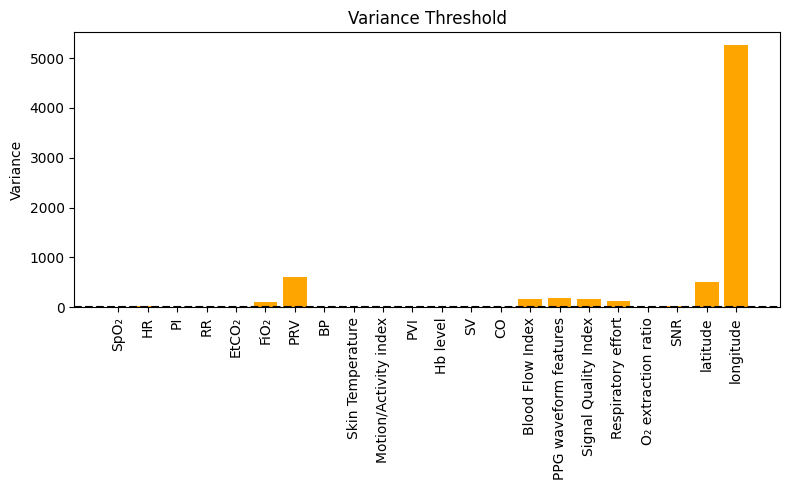

Kept 21 features after Variance Threshold:
['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'SNR', 'latitude', 'longitude']


In [42]:
data = df1
# Select only numeric columns
X = data.drop(columns=['oximetry'])
X = X.select_dtypes(include=['number'])  # keep only numeric columns

y = data['oximetry']

# Remove features with very low variance
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

# Get kept feature names
kept_features = X.columns[selector.get_support(indices=True)]

# Plot variance of features
variances = X.var()
plt.figure(figsize=(8,5))
plt.bar(range(len(variances)), variances, color=['orange' if v > 0.01 else 'skyblue' for v in variances])
plt.axhline(y=0.01, color='black', linestyle='--')
plt.xticks(range(len(variances)), X.columns, rotation=90)
plt.title("Variance Threshold")
plt.ylabel("Variance")
plt.tight_layout()
plt.show()

print(f"Kept {len(kept_features)} features after Variance Threshold:")
print(list(kept_features))


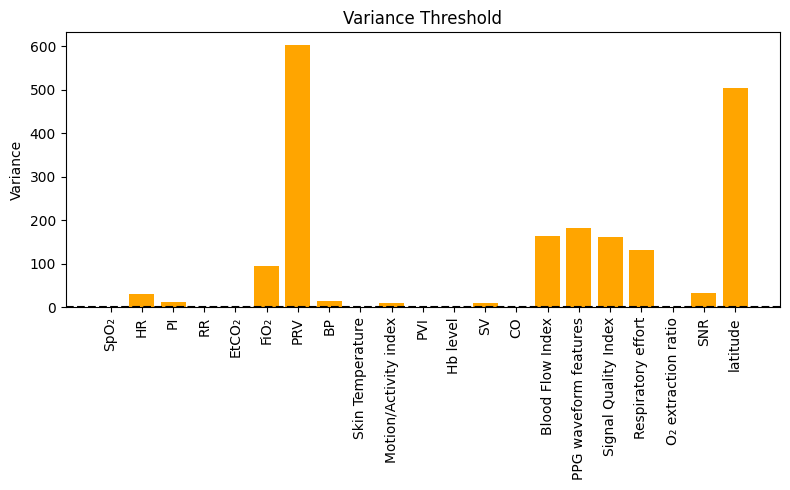

Kept 20 features after Variance Threshold:
['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'SNR', 'latitude']


In [43]:
# Select only numeric columns
X = data.drop(columns=['oximetry'])
X = X.select_dtypes(include=['number'])  # keep only numeric columns

if 'longitude' in X.columns:
    X = X.drop(columns=['longitude'])

y = data['oximetry']

# Remove features with very low variance
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

# Get kept feature names
kept_features = X.columns[selector.get_support(indices=True)]

# Plot variance of features
variances = X.var()
plt.figure(figsize=(8,5))
plt.bar(range(len(variances)), variances, color=['orange' if v > 0.01 else 'skyblue' for v in variances])
plt.axhline(y=0.01, color='black', linestyle='--')
plt.xticks(range(len(variances)), X.columns, rotation=90)
plt.title("Variance Threshold")
plt.ylabel("Variance")
plt.tight_layout()
plt.show()

print(f"Kept {len(kept_features)} features after Variance Threshold:")
print(list(kept_features))


We need to select 10 attributes which are clinically meaningful, numerical and not categorical. The most meaningful dataset for us is the DF1.

Thats why we are analying these 10 attributes:
1. SpO₂, values 0-100 i think. like we dont need decimal numbers
2. HR	we dont need decimal numbers
3.	PI	we need decimal
4.	RR	not decimal
5.	EtCO₂	no decimal
6.	Motion/Activity index no range
7.	PRV	not decimal
8.	BP	not decimal
9.	Skin Temperature not decimal
10.	CO	not decimal

In [97]:
df1[["SpO₂","HR","PI","RR","EtCO₂","Motion/Activity index","PRV","BP","Skin Temperature","CO", 'oximetry']].describe()

,SpO₂,HR,PI,RR,EtCO₂,Motion/Activity index,PRV,BP,Skin Temperature,CO,oximetry
count,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000,12072.000000
mean,97.730285,79.254201,10.016369,15.626983,40.040860,9.830430,107.604654,103.727082,35.397460,4.149888,0.593439
std,0.849037,5.438131,3.437076,0.956935,1.196779,3.075349,24.535197,3.711239,0.711471,0.183781,0.491212
min,95.000000,60.000000,0.200000,12.000000,35.000000,0.729104,20.000000,90.000000,33.000000,4.000000,0.000000
25%,97.107194,75.594604,7.223626,14.987305,39.293217,7.410571,91.139805,101.171379,34.876218,4.050131,0.000000
50%,97.735028,79.184384,10.653755,15.622879,40.078524,9.358351,107.694499,103.768896,35.390370,4.091939,1.000000
75%,98.414264,82.949844,12.634827,16.269205,40.799402,12.479597,124.029275,106.271298,35.918449,4.179315,1.000000
max,100.000000,100.000000,20.000000,20.000000,45.000000,18.997281,200.000000,120.000000,38.000000,8.000000,1.000000


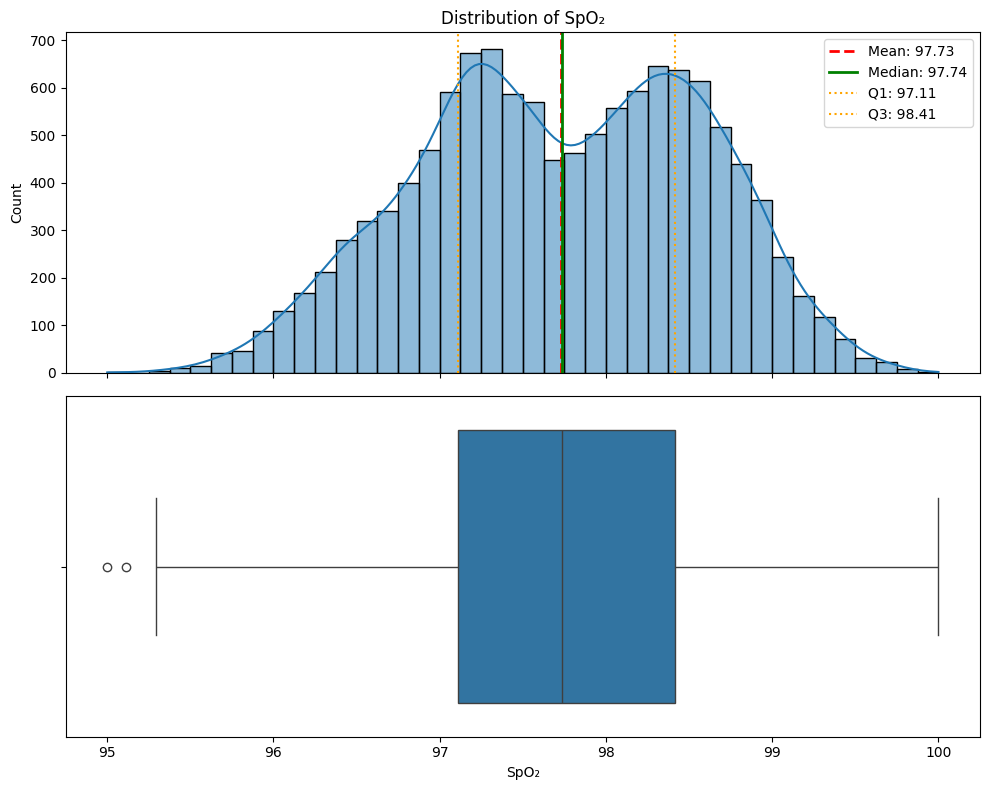


--- SpO₂ ---
count    12072.000000
mean        97.730285
std          0.849037
min         95.000000
25%         97.107194
50%         97.735028
75%         98.414264
max        100.000000
Name: SpO₂, dtype: float64
Skewness: -0.132
Kurtosis: -0.716
⚠️ Probably not normal
Values outside normal range (95–100%): 0
------------------------------------------------------------


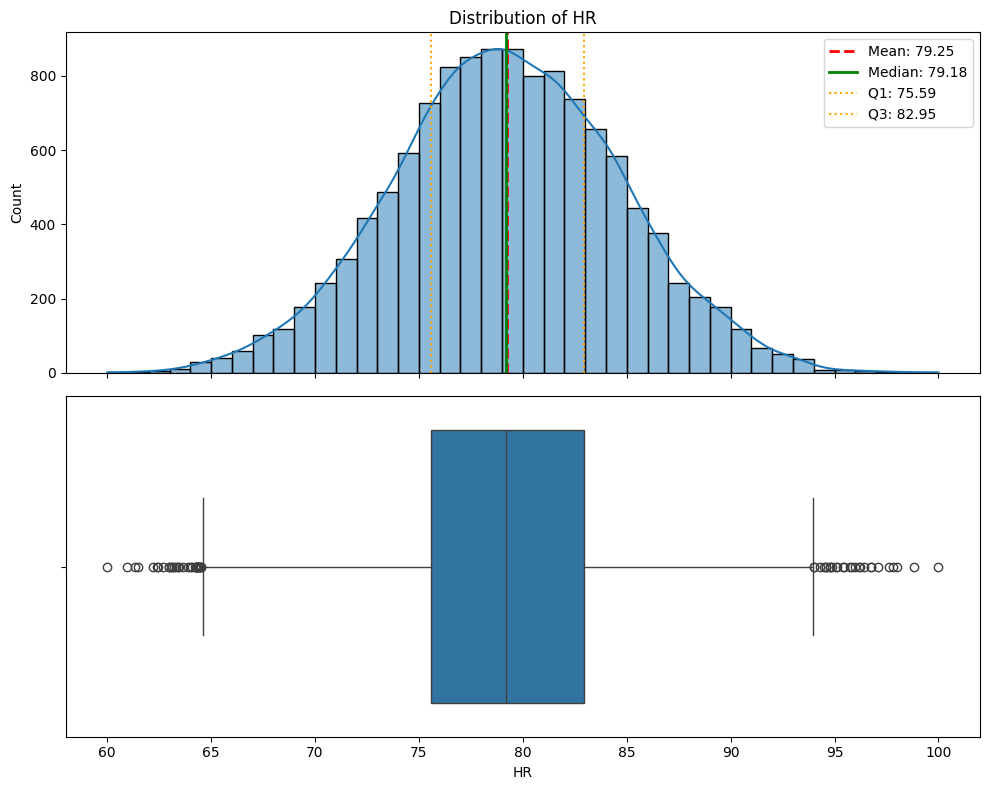


--- HR ---
count    12072.000000
mean        79.254201
std          5.438131
min         60.000000
25%         75.594604
50%         79.184384
75%         82.949844
max        100.000000
Name: HR, dtype: float64
Skewness: 0.010
Kurtosis: -0.071
✅ Probably normal
Values outside normal range (60–100 bpm): 0
------------------------------------------------------------


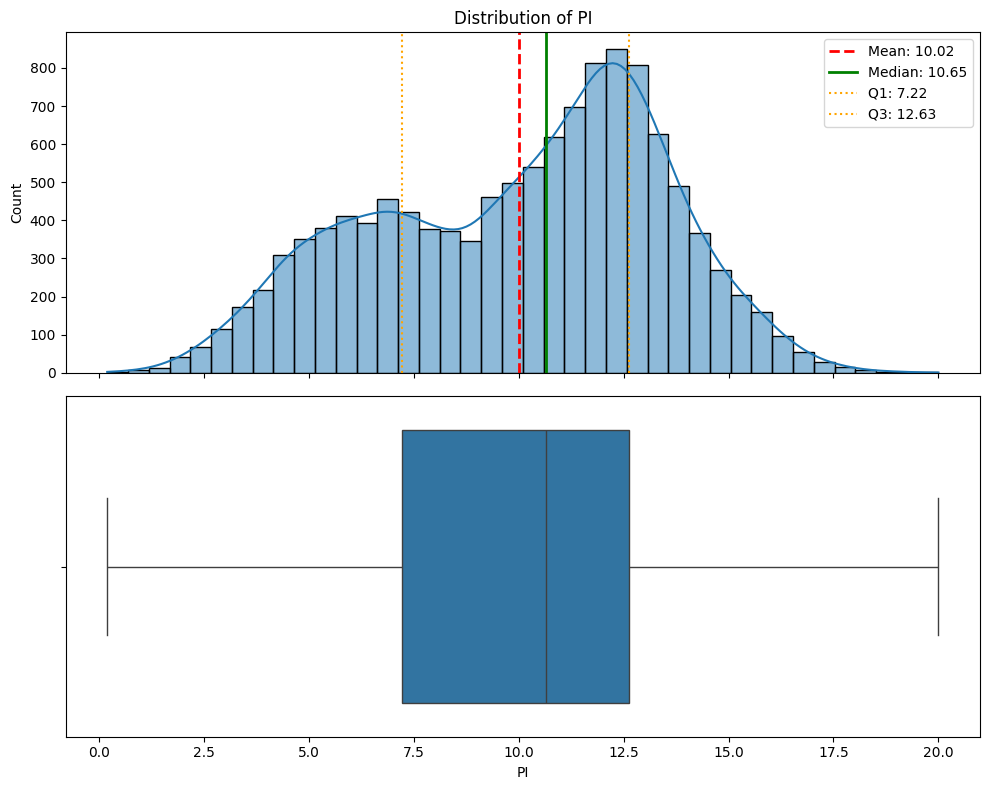


--- PI ---
count    12072.000000
mean        10.016369
std          3.437076
min          0.200000
25%          7.223626
50%         10.653755
75%         12.634827
max         20.000000
Name: PI, dtype: float64
Skewness: -0.313
Kurtosis: -0.761
⚠️ Probably not normal
Values outside normal range (0.2–20%): 0
------------------------------------------------------------


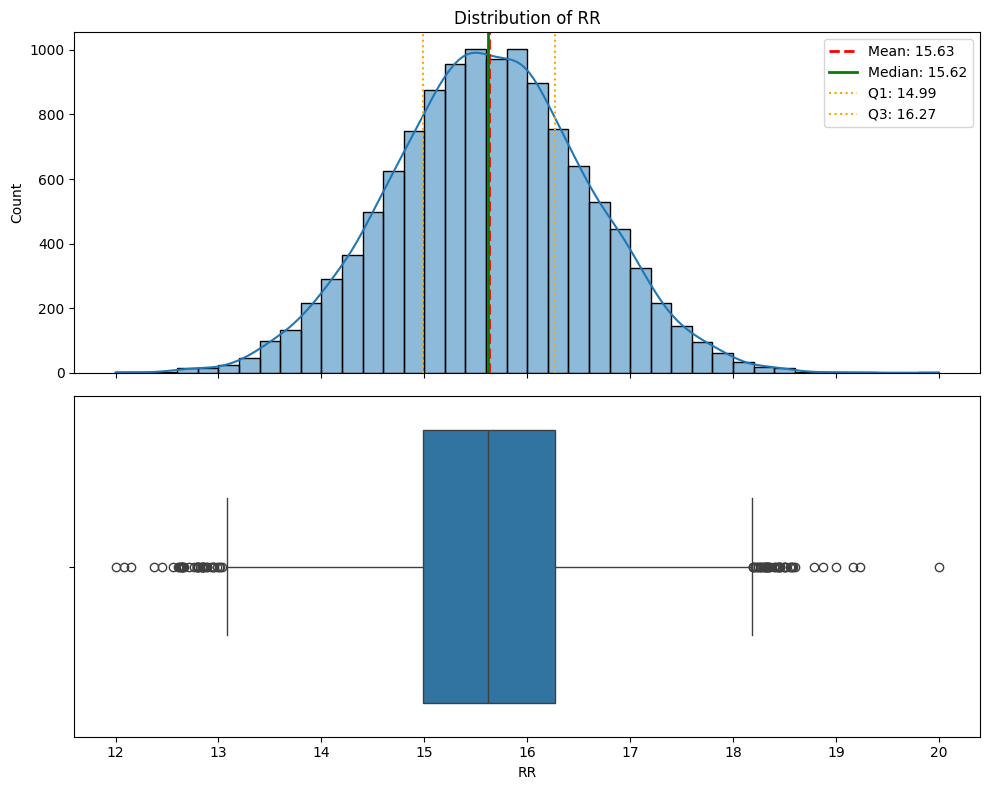


--- RR ---
count    12072.000000
mean        15.626983
std          0.956935
min         12.000000
25%         14.987305
50%         15.622879
75%         16.269205
max         20.000000
Name: RR, dtype: float64
Skewness: 0.001
Kurtosis: -0.012
✅ Probably normal
Values outside normal range (12–20 breaths/min): 0
------------------------------------------------------------


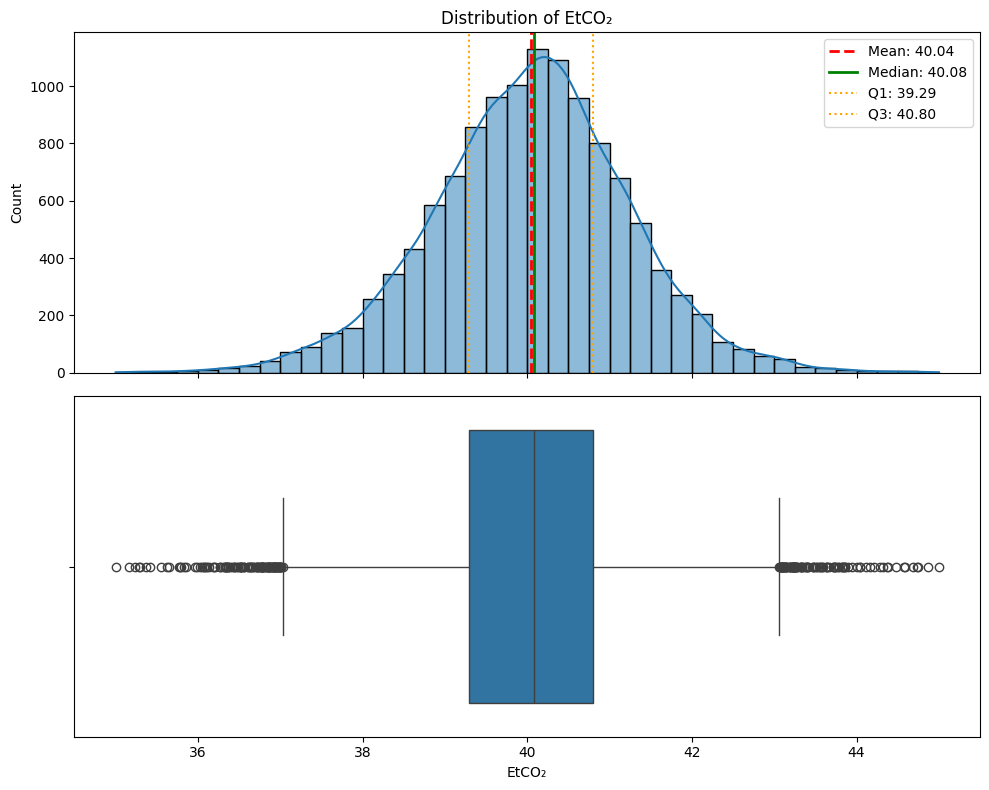


--- EtCO₂ ---
count    12072.000000
mean        40.040860
std          1.196779
min         35.000000
25%         39.293217
50%         40.078524
75%         40.799402
max         45.000000
Name: EtCO₂, dtype: float64
Skewness: -0.082
Kurtosis: 0.572
⚠️ Probably not normal
Values outside normal range (35–45 mmHg): 0
------------------------------------------------------------


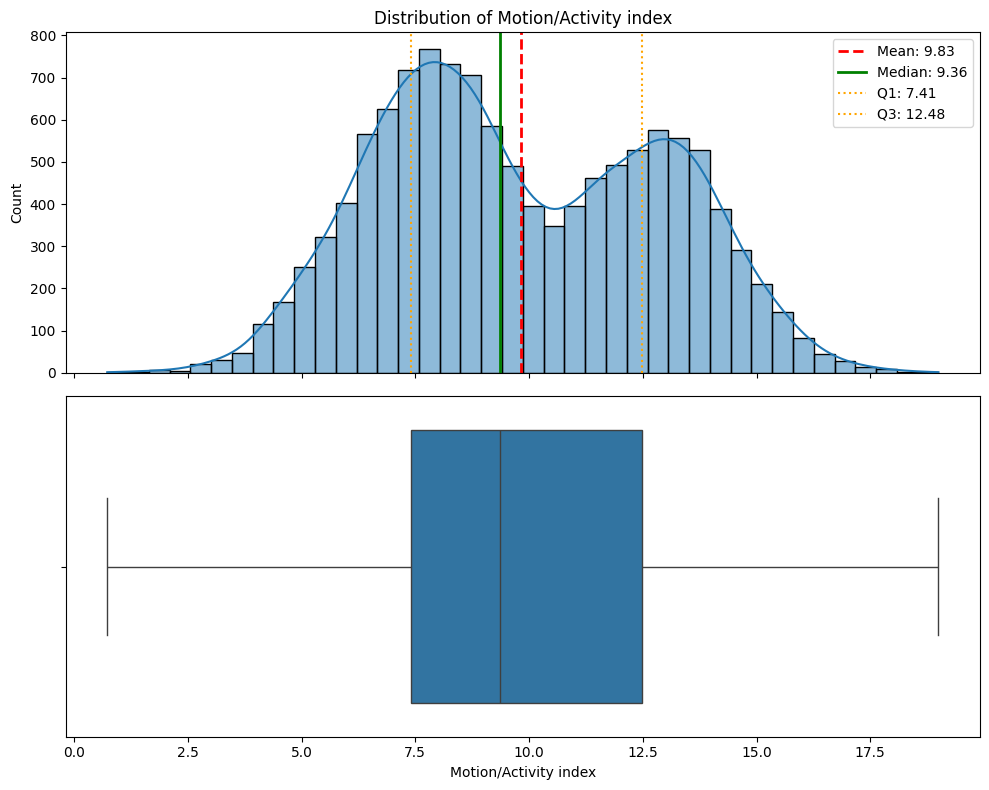


--- Motion/Activity index ---
count    12072.000000
mean         9.830430
std          3.075349
min          0.729104
25%          7.410571
50%          9.358351
75%         12.479597
max         18.997281
Name: Motion/Activity index, dtype: float64
Skewness: 0.146
Kurtosis: -0.885
⚠️ Probably not normal
------------------------------------------------------------


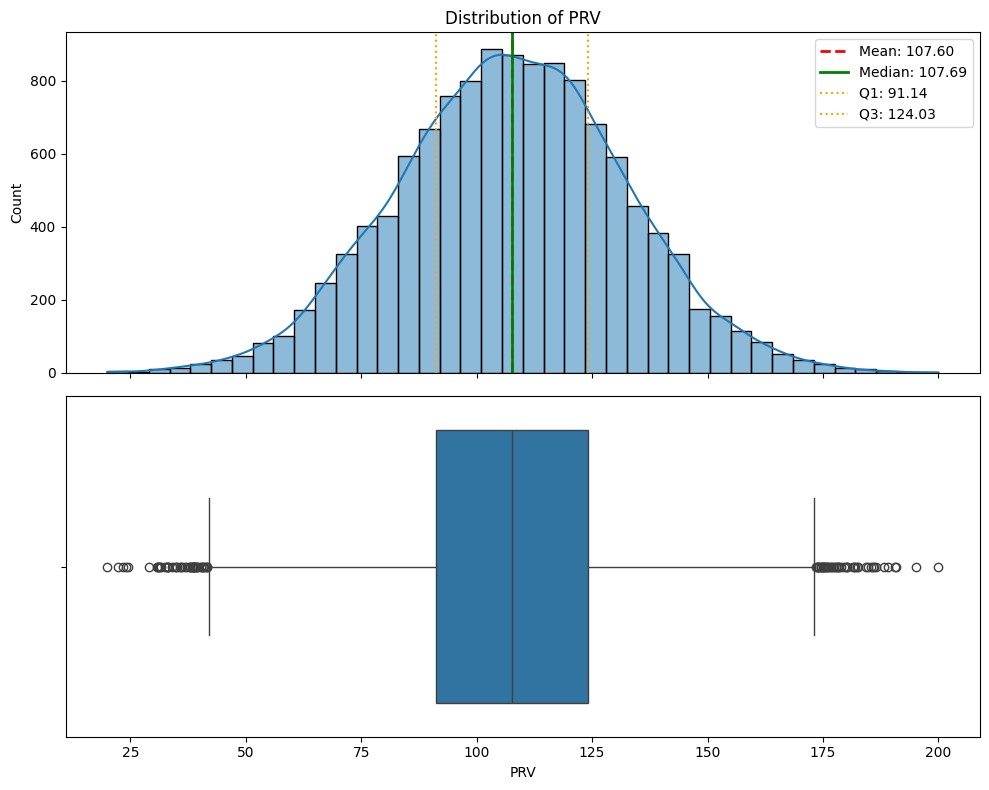


--- PRV ---
count    12072.000000
mean       107.604654
std         24.535197
min         20.000000
25%         91.139805
50%        107.694499
75%        124.029275
max        200.000000
Name: PRV, dtype: float64
Skewness: -0.006
Kurtosis: 0.006
✅ Probably normal
Values outside normal range (20–200 ms): 0
------------------------------------------------------------


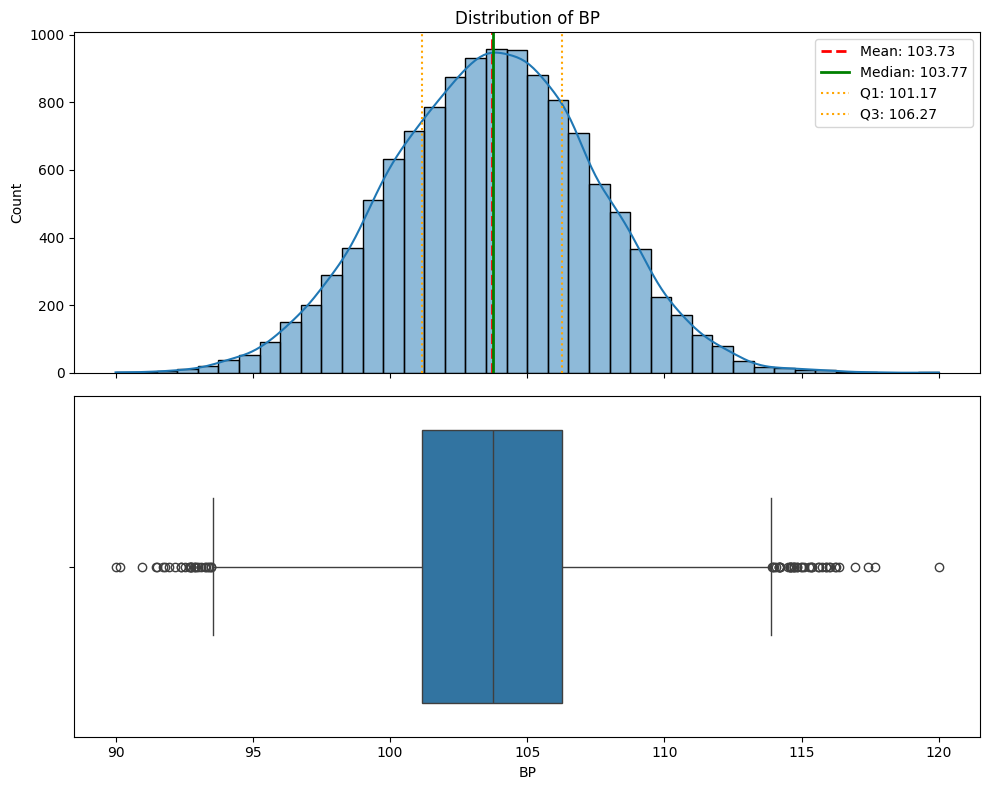


--- BP ---
count    12072.000000
mean       103.727082
std          3.711239
min         90.000000
25%        101.171379
50%        103.768896
75%        106.271298
max        120.000000
Name: BP, dtype: float64
Skewness: -0.015
Kurtosis: -0.042
✅ Probably normal
Values outside normal systolic range (90–120 mmHg): 0
------------------------------------------------------------


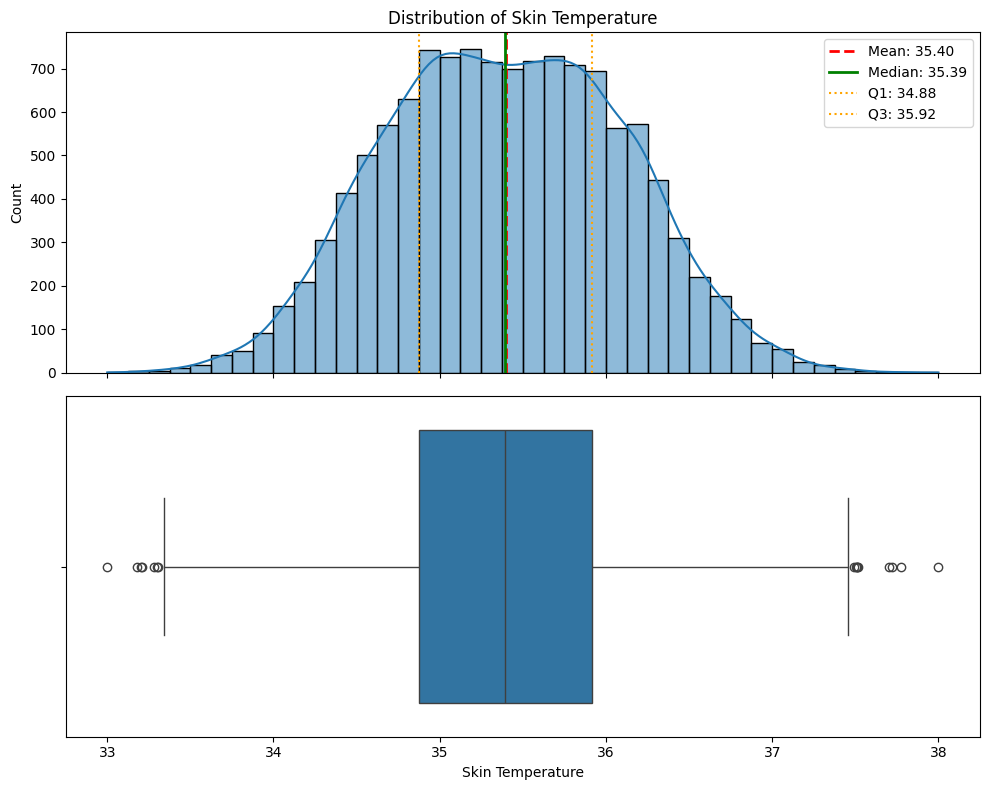


--- Skin Temperature ---
count    12072.000000
mean        35.397460
std          0.711471
min         33.000000
25%         34.876218
50%         35.390370
75%         35.918449
max         38.000000
Name: Skin Temperature, dtype: float64
Skewness: 0.022
Kurtosis: -0.434
⚠️ Probably not normal
Values outside normal range (33–38 °C): 0
------------------------------------------------------------


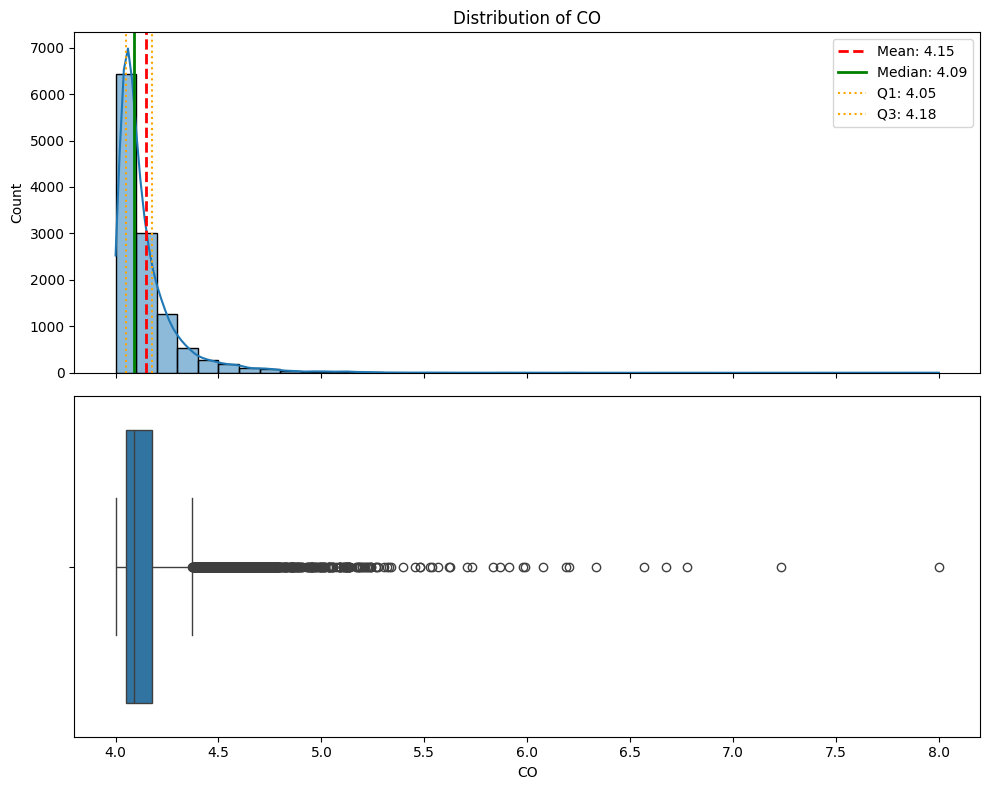


--- CO ---
count    12072.000000
mean         4.149888
std          0.183781
min          4.000000
25%          4.050131
50%          4.091939
75%          4.179315
max          8.000000
Name: CO, dtype: float64
Skewness: 4.918
Kurtosis: 48.463
⚠️ Probably not normal
Values outside normal range (4–8 L/min): 0
------------------------------------------------------------


In [34]:
numeric_cols = ['SpO₂','HR','PI','RR','EtCO₂','Motion/Activity index','PRV','BP','Skin Temperature','CO']

for col in numeric_cols:
    # Create figure with 2 subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Top plot: Histogram with KDE
    sns.histplot(df1[col], bins=40, kde=True, ax=ax1)
    
    # Calculate statistics
    mean_val = df1[col].mean()
    median_val = df1[col].median()
    q1 = df1[col].quantile(0.25)
    q3 = df1[col].quantile(0.75)
    
    # Add vertical lines for mean, median, Q1, Q3 on histogram
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.axvline(q1, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q1:.2f}')
    ax1.axvline(q3, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q3:.2f}')
    ax1.set_title(f'Distribution of {col}')
    ax1.legend()
    
    # Bottom plot: Boxplot (horizontal)
    sns.boxplot(x=df1[col], ax=ax2)
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n--- {col} ---")
    print(df1[col].describe())  
    print(f"Skewness: {df1[col].skew():.3f}")
    print(f"Kurtosis: {df1[col].kurt():.3f}")
    
    # Normality test
    stat, p = normaltest(df1[col].dropna())
    if p > 0.05:
        print("✅ Probably normal")
    else:
        print("⚠️ Probably not normal")
    
    # Range checks
    if col == 'SpO₂':
        invalid = df1[(df1[col] < 95) | (df1[col] > 100)]
        print(f"Values outside normal range (95–100%): {len(invalid)}")
    elif col == 'HR':
        invalid = df1[(df1[col] < 60) | (df1[col] > 100)]
        print(f"Values outside normal range (60–100 bpm): {len(invalid)}")
    elif col == 'RR':
        invalid = df1[(df1[col] < 12) | (df1[col] > 20)]
        print(f"Values outside normal range (12–20 breaths/min): {len(invalid)}")
    elif col == 'BP':
        invalid = df1[(df1[col] < 90) | (df1[col] > 120)]
        print(f"Values outside normal systolic range (90–120 mmHg): {len(invalid)}")
    elif col == 'Skin Temperature':
        invalid = df1[(df1[col] < 33) | (df1[col] > 38)]
        print(f"Values outside normal range (33–38 °C): {len(invalid)}")
    elif col == 'EtCO₂':
        invalid = df1[(df1[col] < 35) | (df1[col] > 45)]
        print(f"Values outside normal range (35–45 mmHg): {len(invalid)}")
    elif col == 'FiO₂':
        invalid = df1[(df1[col] < 21) | (df1[col] > 100)]
        print(f"Values outside normal range (21–100%): {len(invalid)}")
    elif col == 'PI':
        invalid = df1[(df1[col] < 0.2) | (df1[col] > 20)]
        print(f"Values outside normal range (0.2–20%): {len(invalid)}")
    elif col == 'PRV':
        invalid = df1[(df1[col] < 20) | (df1[col] > 200)]
        print(f"Values outside normal range (20–200 ms): {len(invalid)}")
    elif col == 'CO':
        invalid = df1[(df1[col] < 4) | (df1[col] > 8)]
        print(f"Values outside normal range (4–8 L/min): {len(invalid)}")
    print("-" * 60)

1. SpO₂ - bimodial distribution
2. HR - normal distribution
3. PI - left scewed
4. RR - normal distribution
5. EtCO₂ - slightly left scewed
6. Motion/Activity index - bimodal
7. PRV - normal distribution
8. BP - follows normal distribution
9. Skin Temperature - symetrical
10. CO - exponential

# 1.2 C - observation

# TOTO CHECKNI DAMIAN CI JE DOBRE //everything ok

# IQR method1

In [42]:
Q1 = dff1['HR'].quantile(0.25)
Q3 = dff1['HR'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers1 = dff1[(dff1['HR'] < lower_bound) | (dff1['HR'] > upper_bound)]
print(len(outliers1))

63


# Percentile method

In [43]:
lower = dff1['HR'].quantile(0.05)
upper = dff1['HR'].quantile(0.95)

outliers2 = dff1[(dff1['HR'] < lower) | (dff1['HR'] > upper)]
print(len(outliers2))

1208


In [44]:
# Drop outliers use the bounding we used the first one because we lose too many data
dff1 = dff1[(df1['HR'] >= lower_bound) & (dff1['HR'] <= upper_bound)]
print(f"Po odstránení: {dff1.shape[0]} záznamov zostalo")

dff3 = dff3.reset_index(drop=True)

Po odstránení: 12009 záznamov zostalo


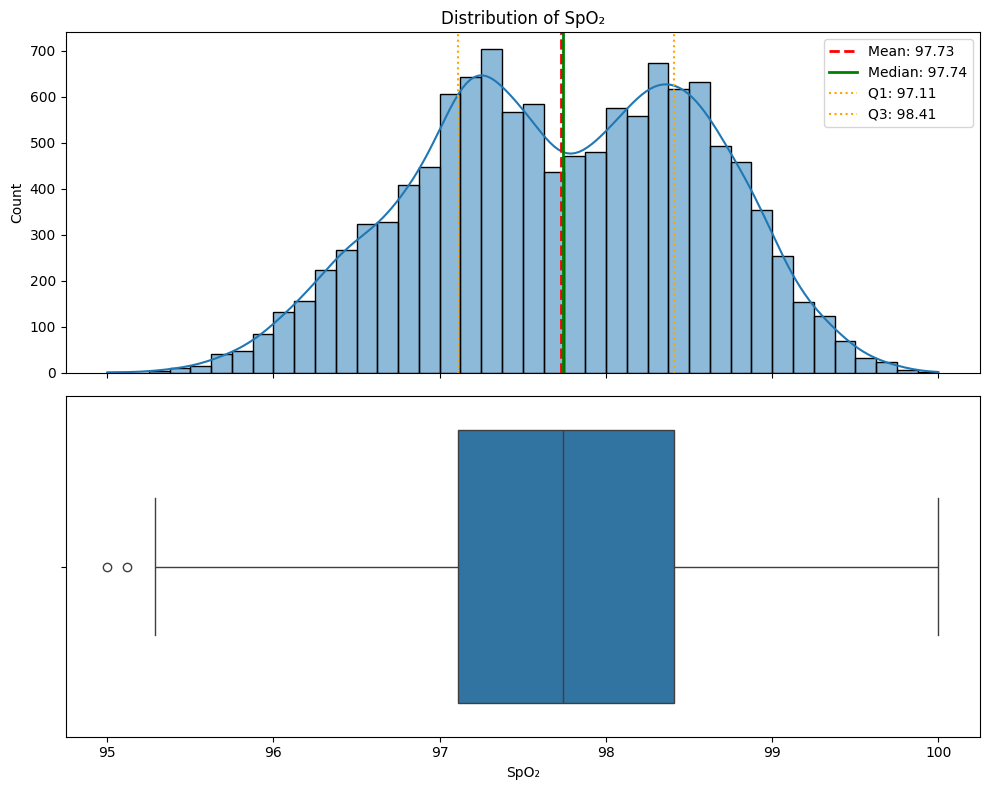


--- SpO₂ ---
count    12072.000000
mean        97.730285
std          0.849037
min         95.000000
25%         97.107194
50%         97.735028
75%         98.414264
max        100.000000
Name: SpO₂, dtype: float64
Skewness: -0.134
Kurtosis: -0.714
⚠️ Probably not normal


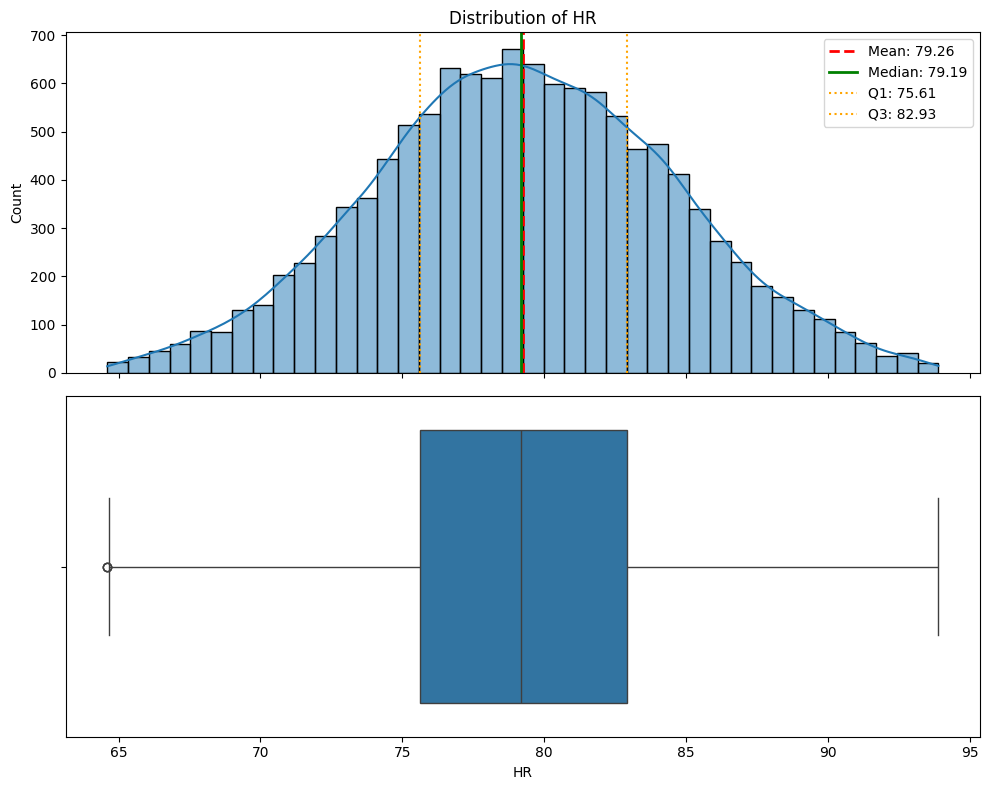


--- HR ---
count    12072.000000
mean        79.254201
std          5.438131
min         60.000000
25%         75.594604
50%         79.184384
75%         82.949844
max        100.000000
Name: HR, dtype: float64
Skewness: 0.011
Kurtosis: -0.264
⚠️ Probably not normal


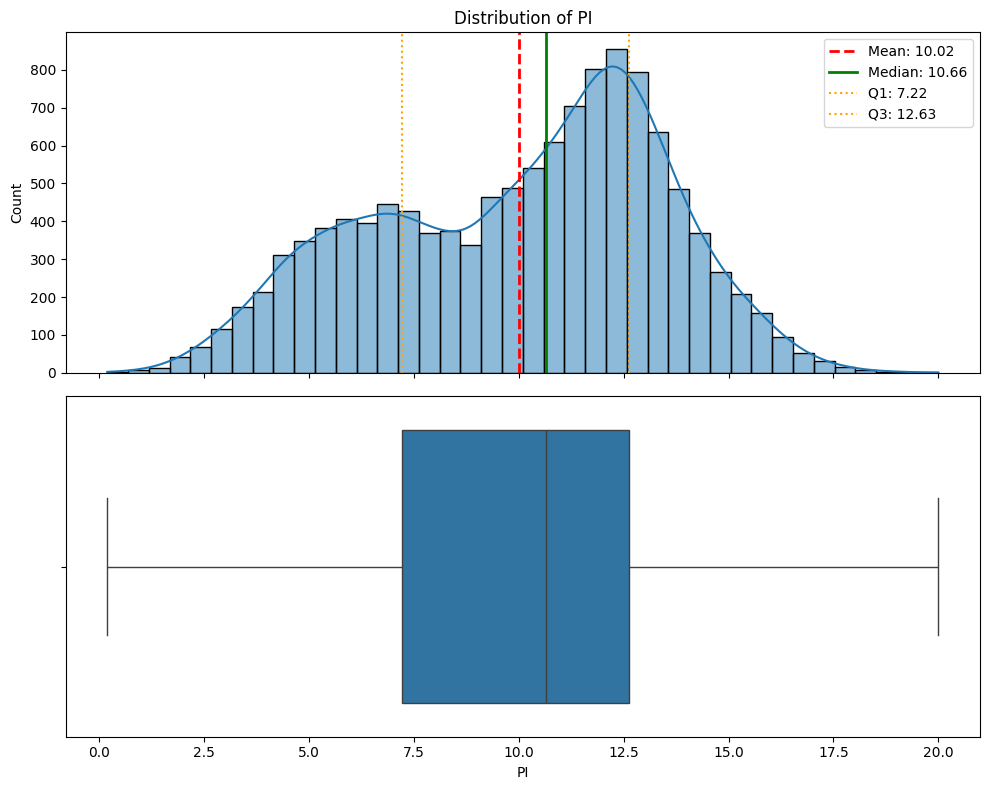


--- PI ---
count    12072.000000
mean        10.016369
std          3.437076
min          0.200000
25%          7.223626
50%         10.653755
75%         12.634827
max         20.000000
Name: PI, dtype: float64
Skewness: -0.314
Kurtosis: -0.762
⚠️ Probably not normal


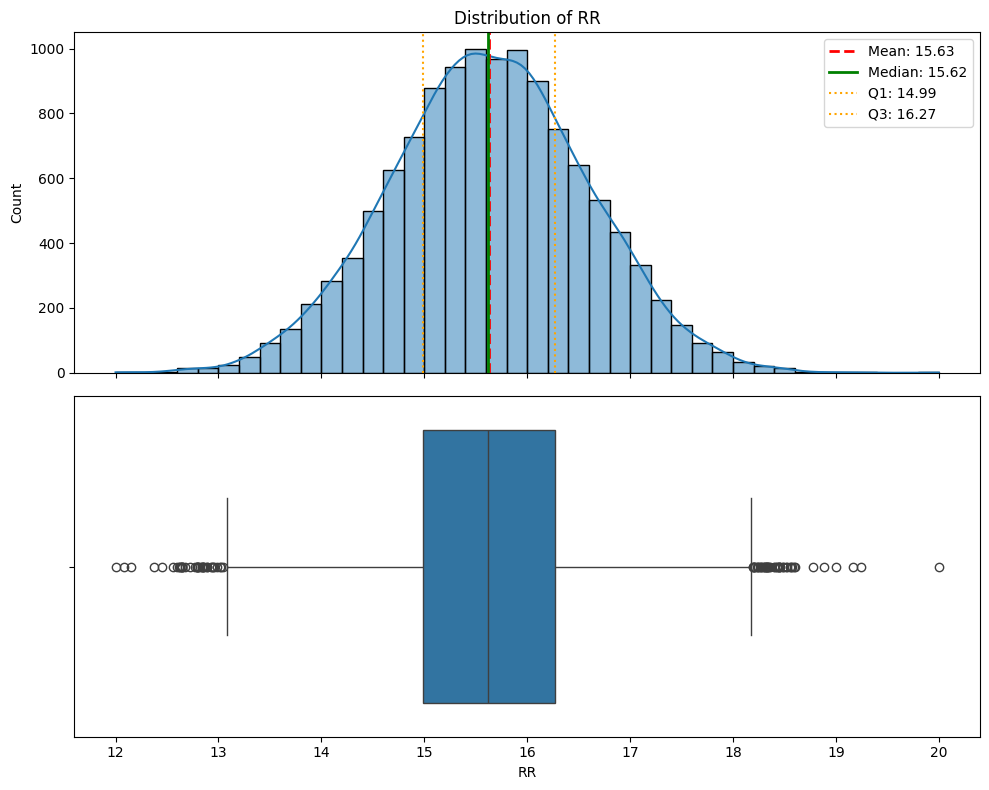


--- RR ---
count    12072.000000
mean        15.626983
std          0.956935
min         12.000000
25%         14.987305
50%         15.622879
75%         16.269205
max         20.000000
Name: RR, dtype: float64
Skewness: 0.002
Kurtosis: -0.014
✅ Probably normal


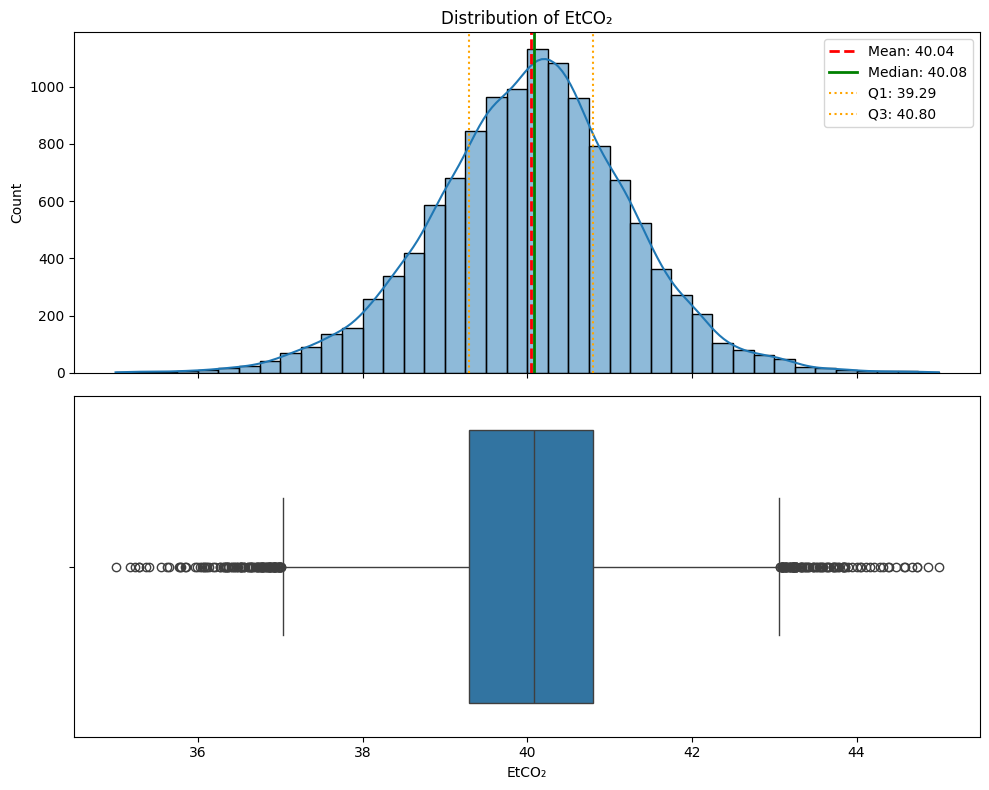


--- EtCO₂ ---
count    12072.000000
mean        40.040860
std          1.196779
min         35.000000
25%         39.293217
50%         40.078524
75%         40.799402
max         45.000000
Name: EtCO₂, dtype: float64
Skewness: -0.080
Kurtosis: 0.573
⚠️ Probably not normal


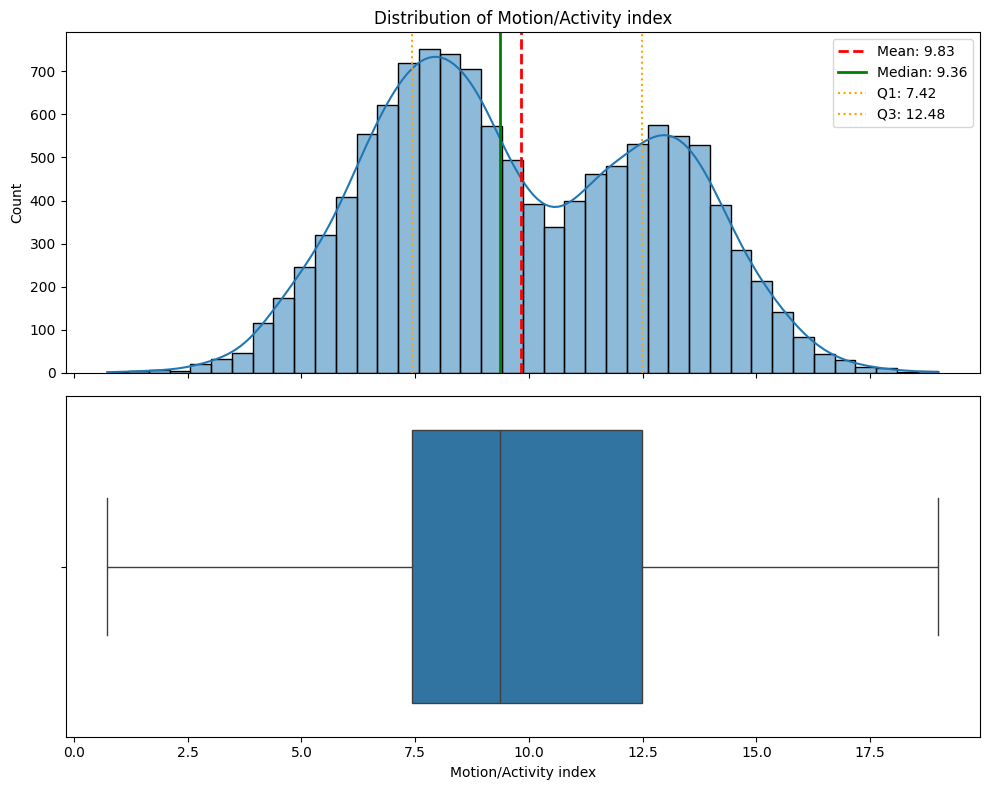


--- Motion/Activity index ---
count    12072.000000
mean         9.830430
std          3.075349
min          0.729104
25%          7.410571
50%          9.358351
75%         12.479597
max         18.997281
Name: Motion/Activity index, dtype: float64
Skewness: 0.145
Kurtosis: -0.885
⚠️ Probably not normal


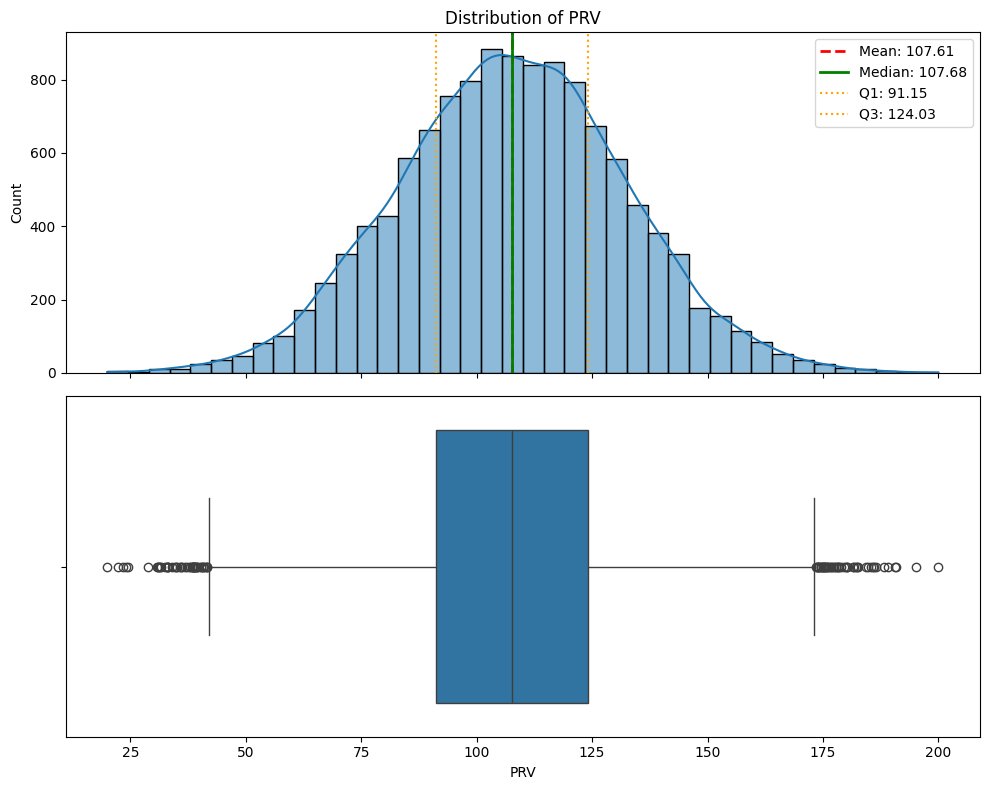


--- PRV ---
count    12072.000000
mean       107.604654
std         24.535197
min         20.000000
25%         91.139805
50%        107.694499
75%        124.029275
max        200.000000
Name: PRV, dtype: float64
Skewness: -0.003
Kurtosis: 0.002
✅ Probably normal


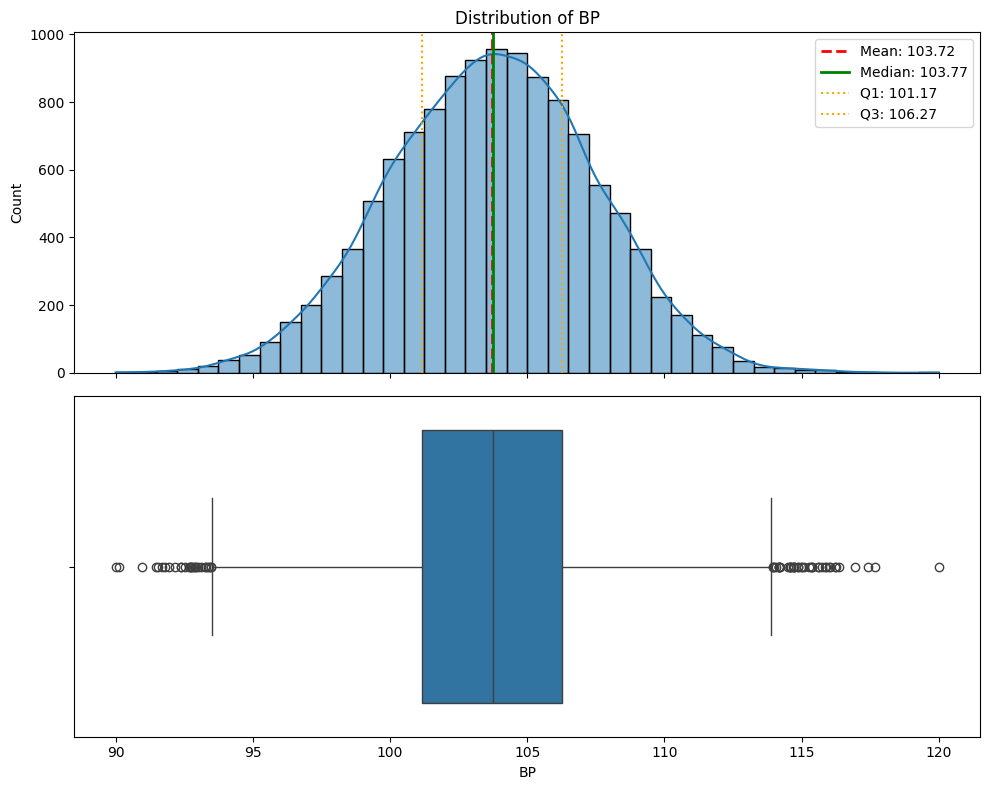


--- BP ---
count    12072.000000
mean       103.727082
std          3.711239
min         90.000000
25%        101.171379
50%        103.768896
75%        106.271298
max        120.000000
Name: BP, dtype: float64
Skewness: -0.014
Kurtosis: -0.040
✅ Probably normal


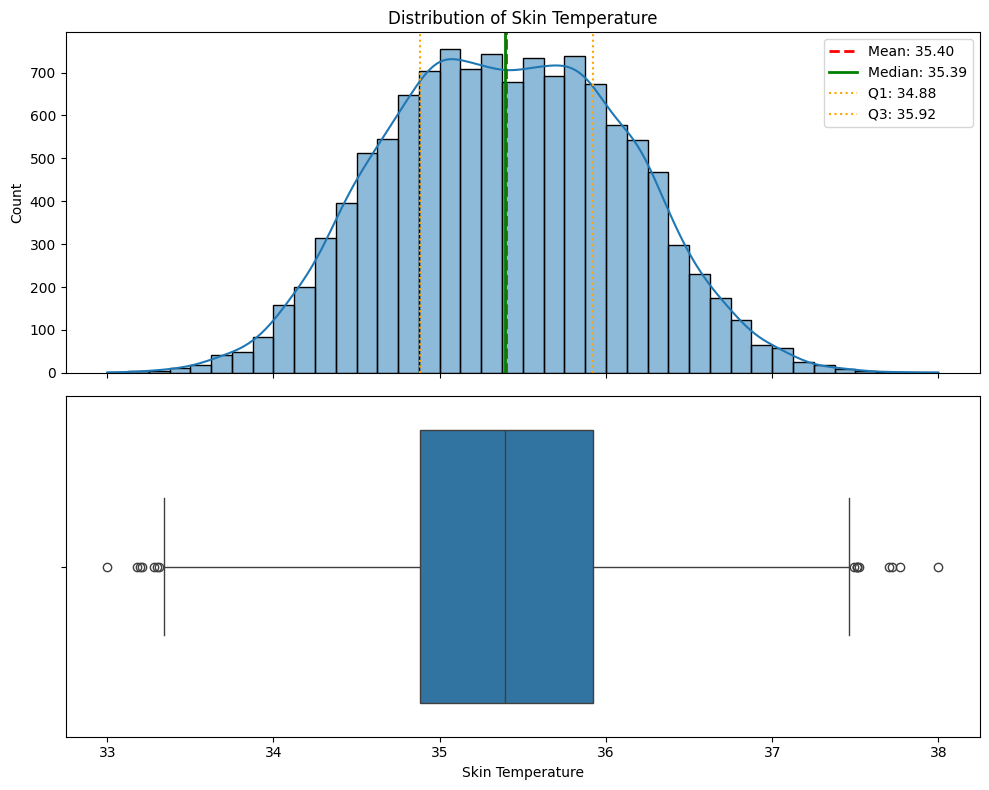


--- Skin Temperature ---
count    12072.000000
mean        35.397460
std          0.711471
min         33.000000
25%         34.876218
50%         35.390370
75%         35.918449
max         38.000000
Name: Skin Temperature, dtype: float64
Skewness: 0.021
Kurtosis: -0.433
⚠️ Probably not normal


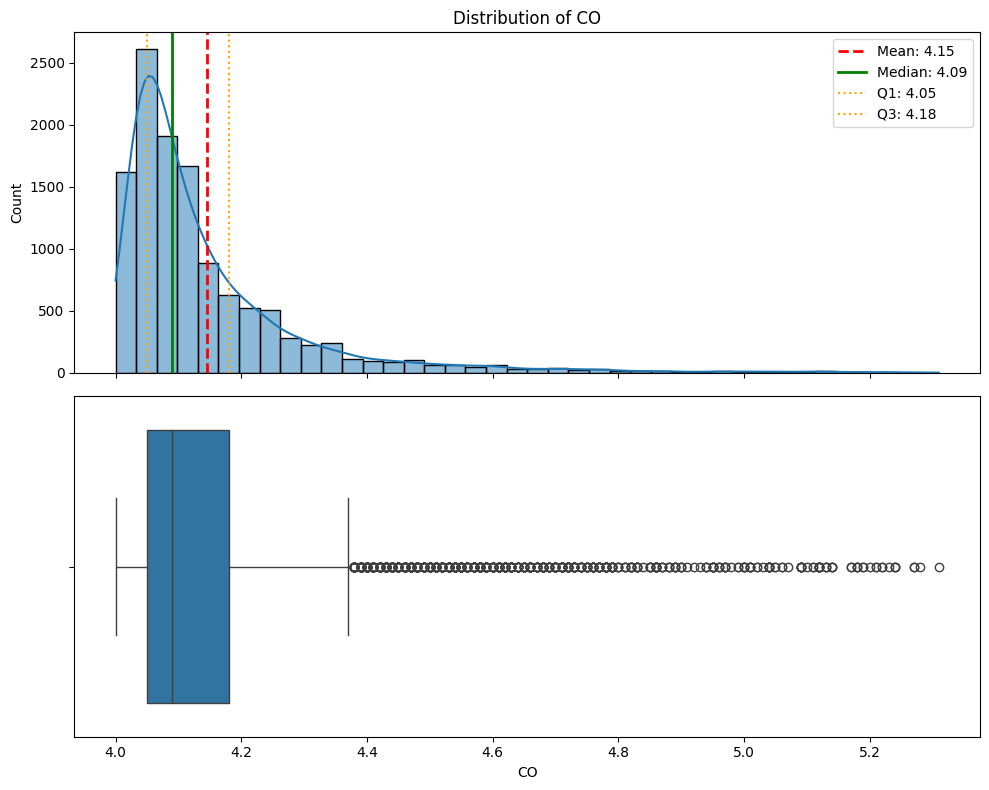


--- CO ---
count    12072.000000
mean         4.149888
std          0.183781
min          4.000000
25%          4.050131
50%          4.091939
75%          4.179315
max          8.000000
Name: CO, dtype: float64
Skewness: 2.859
Kurtosis: 10.814
⚠️ Probably not normal


In [45]:
numeric_cols = ['SpO₂','HR','PI','RR','EtCO₂','Motion/Activity index','PRV','BP','Skin Temperature','CO']

for col in numeric_cols:
    # Create figure with 2 subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Top plot: Histogram with KDE
    sns.histplot(dff1[col], bins=40, kde=True, ax=ax1)
    
    # Calculate statistics
    mean_val = dff1[col].mean()
    median_val = dff1[col].median()
    q1 = dff1[col].quantile(0.25)
    q3 = dff1[col].quantile(0.75)
    
    # Add vertical lines for mean, median, Q1, Q3 on histogram
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.axvline(q1, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q1:.2f}')
    ax1.axvline(q3, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q3:.2f}')
    ax1.set_title(f'Distribution of {col}')
    ax1.legend()
    
    # Bottom plot: Boxplot (horizontal)
    sns.boxplot(x=dff1[col], ax=ax2)
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n--- {col} ---")
    print(df1[col].describe())  
    print(f"Skewness: {dff1[col].skew():.3f}")
    print(f"Kurtosis: {dff1[col].kurt():.3f}")
    
    # Normality test
    stat, p = normaltest(dff1[col].dropna())
    if p > 0.05:
        print("✅ Probably normal")
    else:
        print("⚠️ Probably not normal")

# 1.1 C

### Identify relationships between attributes = Dependencies e.g. correlations 
**Bivariate analysis = Pair analysis**

In [46]:
numeric_cols.append('oximetry')

we append a predicted variable to the numeric_col so we can made corelation matrices and compare the values

### Pearson correlation heat map

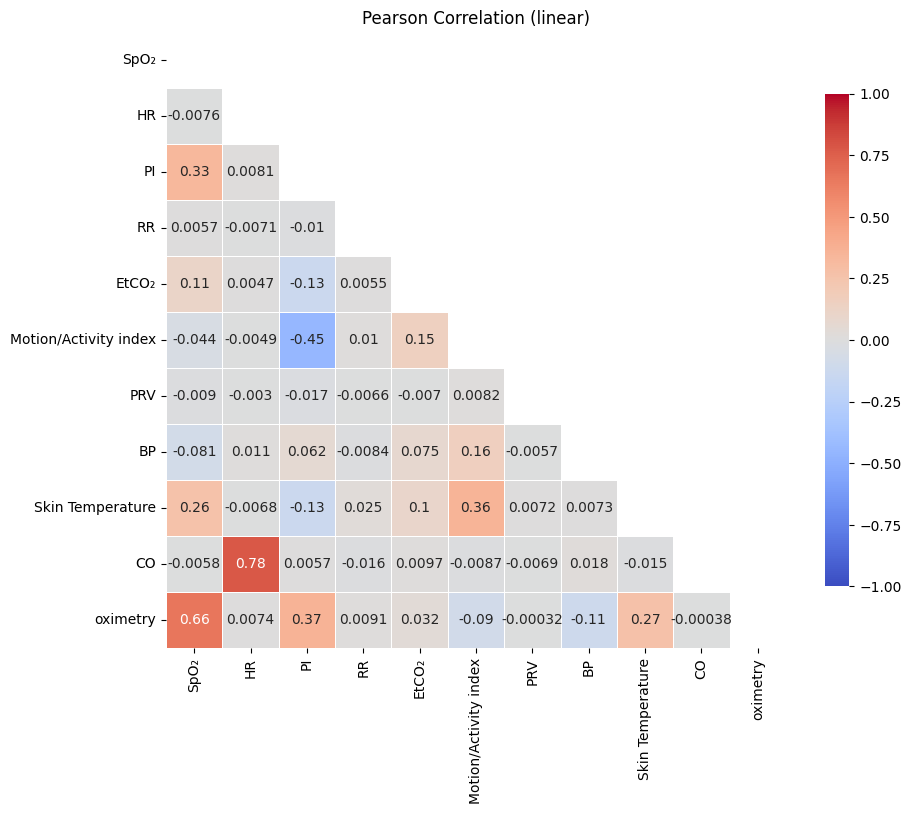

In [47]:
# Compute correlation matrix
corr = df1[numeric_cols].corr(method='pearson')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the lower triangular heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,          # mask upper part
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Pearson Correlation (linear)')
plt.show()


### Spearman correlation heatmap

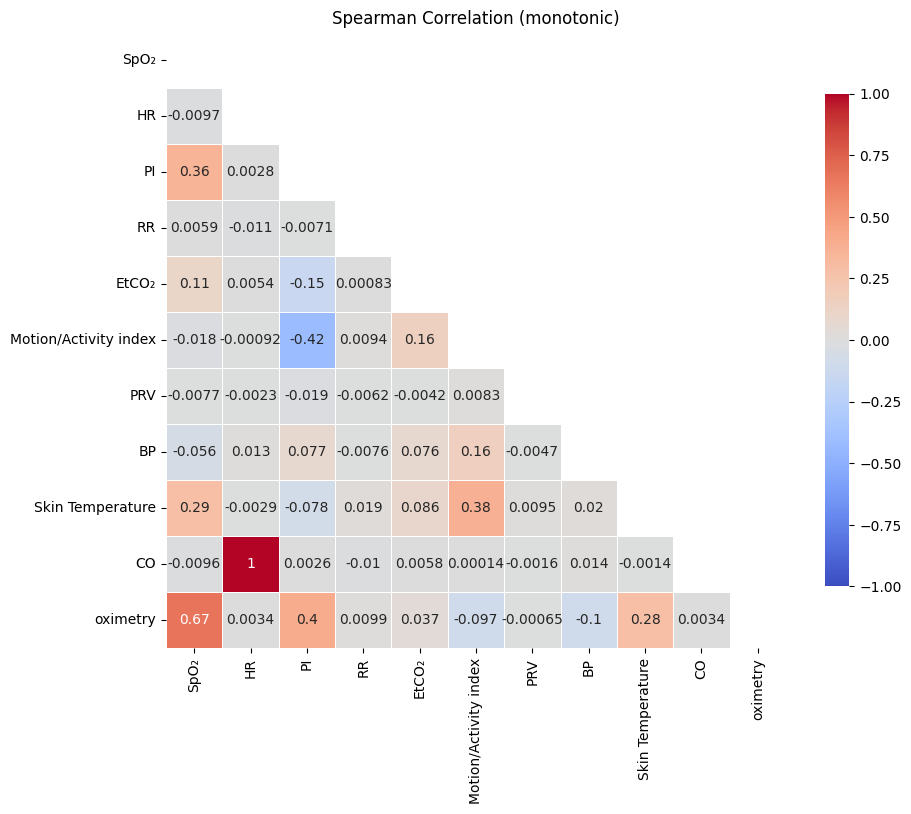

In [48]:
# Compute correlation matrix
corr2 = df1[numeric_cols].corr(method='spearman')

# Create a mask for the upper triangle
mask2 = np.triu(np.ones_like(corr2, dtype=bool))

# Plot the lower triangular heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr2,
    mask=mask2,          # mask upper part
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Spearman Correlation (monotonic)')
plt.show()

# 1.1 D

## Identify the dependencies between the predicted variable and the other variables (potential predictors)


From Spearman and Pearson matrices we identified these significant factors:
SpO₂ shows a strong positive correlation with oximetry(0.66/0.67).

Perfusion Index (PI) demonstrates a moderate positive correlation(0.4/0.37).

Skin temperature exhibits a weaker, yet still notable positive correlation above the defined threshold(0.28/0.27).

Blood Preassure exhibits a very week negative correlation(borderline value) however there can be relationship between these values(-0.1/-0.11).

Motion/Activity index also shows a very week negative correlation(borderline value) and is also can possibly have relationship with oximetry(-0.097/-0.09)

Since oximetry data contains just two values, we can safely say that the data is not normal(the data are discrete and normal distribution is always
continuos). And from normality tests above, we also know that the Sp0₂, PI and Skin Temperature data does not come from normal distribution so we can do the Spearman test.


In [74]:
def analyze_oximetry_correlations(df):
    pairs = {
        "SpO₂": "SpO₂",
        "Perfusion Index": "PI",
        "Skin Temperature": "Skin Temperature",
        "Blood Pressure": "BP",
        "Motion/Activity Index": "Motion/Activity index"
    }

    results = []

    print("=== Spearman Correlation Analysis with Oximetry ===\n")

    for label, col in pairs.items():
        rho, p = spearmanr(df['oximetry'], df[col])
        results.append({"Parameter": label, "rho": rho, "p_value": p, "Significant": p < 0.05})

        print(f"Oximetry vs {label}: rho = {rho:.3f}, p = {p:.3e}")
        if p < 0.05:
            print("   → Statistically significant monotonic relationsh")
        else:
            print("   → No statistically significant relationship ")
        print()

    return pd.DataFrame(results)
result_df =analyze_oximetry_correlations(dff1)

=== Spearman Correlation Analysis with Oximetry ===

Oximetry vs SpO₂: rho = 0.667, p = 0.000e+00
   → Statistically significant monotonic relationsh

Oximetry vs Perfusion Index: rho = 0.401, p = 0.000e+00
   → Statistically significant monotonic relationsh

Oximetry vs Skin Temperature: rho = 0.284, p = 3.297e-221
   → Statistically significant monotonic relationsh

Oximetry vs Blood Pressure: rho = -0.101, p = 8.677e-29
   → Statistically significant monotonic relationsh

Oximetry vs Motion/Activity Index: rho = -0.096, p = 4.292e-26
   → Statistically significant monotonic relationsh



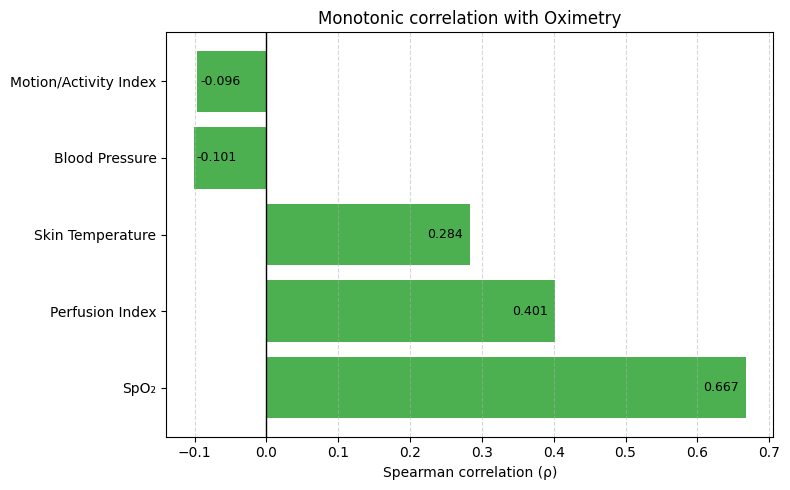

In [75]:
def plot_oximetry_correlations(df):
    plt.figure(figsize=(8, 5))
    bars = plt.barh(df["Parameter"], df["rho"],
                    color=df["Significant"].map({True: "#4CAF50", False: "#B0BEC5"}))

    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel("Spearman correlation (ρ)")
    plt.title("Monotonic correlation with Oximetry")
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    for bar, rho in zip(bars, df["rho"]):
        plt.text(bar.get_width() - 0.06 if rho > 0 else bar.get_width() + 0.06,
                 bar.get_y() + bar.get_height()/2,
                 f"{rho:.3f}",
                 va='center', ha='left' if rho > 0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_oximetry_correlations(result_df)

Using the Spearman correlation test, we found a statistically significant monotonic relationship between oximetry and all potentional predictors are in statistically significant relationshp

# 1.1 E

## Document your initial thoughts on solving the project assignment. For example: Are some attributes dependent on each other? Which attributes influence the predicted variable? Is it necessary to combine records from multiple files?

 When looking at the dataset, we need to find out the potential dependencies between attributes and determine which of them could influence the predicted variable, oxygen saturation (SpO₂).

Thus we have calculated both Pearson and Spearman correlation matrixes, to find out tha the Perfusion Index(PI) and Skin Temperature showed the strongest associantons with SpO₂. Although the correlation coefficients were relatively low (ρ ≈ 0.36 for PI and ρ ≈ 0.26 for Skin Temperature), the Spearman test confirmed that these relationships are statistically significant.

The dataset used for this stage of the project contained all required variables within a single file, so combining multiple data sources was not necessary at this point.

# 1.3

## Formulate two hypotheses about the data in the context of the given predictive task. Verify the formulated hypotheses using appropriately chosen statistical tests.


Since we know the parameters that are in relationship with predicted value we can form a hypotesis that will help us to further more predict the effects that will be formed between values. Our hypotesis:

## $H_0$ = The variance of PI is the same in the oximetry = 0 group as in the oximetry = 1 group.

## $H_1$ = The variance of PI is not the same in the oximetry = 0  as in the oximetry = 1 group

In [58]:
hpc1 = dff1[['PI','oximetry']]
hpc1.head()

,PI,oximetry
0,13.66,1.0
1,4.45,1.0
2,14.23,1.0
3,3.30,1.0
4,4.81,0.0


In [59]:
hpc1.describe()

,PI,oximetry
count,12009.000000,12009.000000
mean,10.015130,0.593555
std,3.438178,0.491190
min,0.200000,0.000000
25%,7.220000,0.000000
50%,10.660000,1.000000
75%,12.630000,1.000000
max,20.000000,1.000000


In [70]:
hpc1['oximetry'].unique()
counts = hpc1['oximetry'].value_counts()
counts

oximetry
1.0    7128
0.0    4881
Name: count, dtype: int64

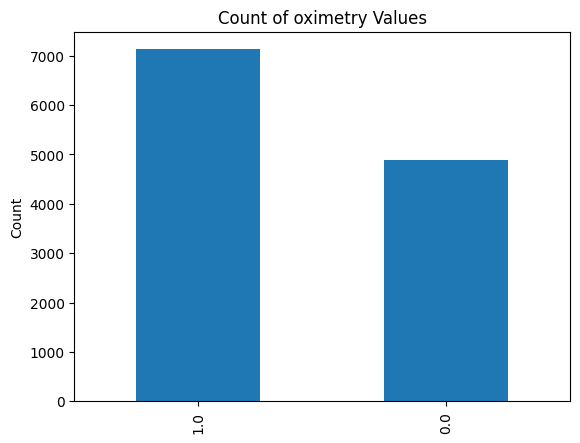

In [73]:
counts.plot(kind='bar')
plt.xlabel('')
plt.ylabel('Count')
plt.title('Count of oximetry Values')
plt.show()


<Axes: xlabel='oximetry', ylabel='PI'>

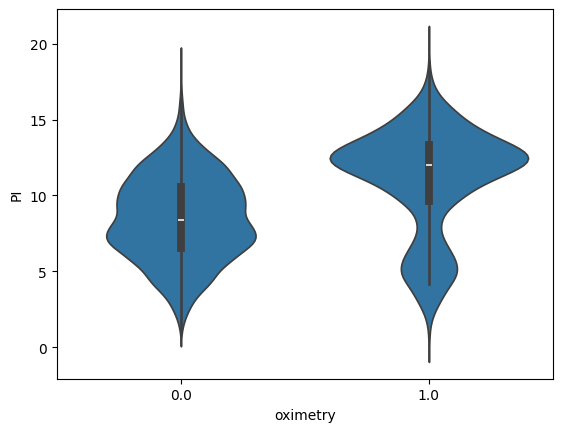

In [72]:
sns.violinplot(x="oximetry", y="PI", data=hpc1)

From the violin above, we can see that the distribution of PI could be a difference between oximetry = 1 group and oximetry = 0 with respect to PI suqquesting a potential difference in variance. However the visual observation should be confirmed with statistical tests.

In [38]:

sns.histplot(x='oximetry', y='PI', data= hpc1)

NameError: name 'hpc1' is not defined